In [3]:
# 폰트 다운 필요시 사용
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf



## 목차

#### 1. 데이터 탐색 (EDA)
- 데이터 품질 확인
- 기초 통계량 및 분포 확인

#### 2. 데이터 전처리

#### 3. 고객 세분화
- RFM 분석
- K-means Clustering

#### 4. 클러스터별 특성 분석
- 클러스터별 정보 확인
- 마케팅비용 확인
- 구매 주기 확인

#### 5. Cohort 분석
- 전체 Cohort 분석
- 군집별 Cohort 분석

#### 6. Clustering 결과 해석


In [4]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import datetime as dt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.pylab import rcParams
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
from IPython.display import Image
import warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
online_sales = pd.read_csv('/content/drive/MyDrive/데이콘 이커머스 고객 세분화/data/open (5)/Onlinesales_info.csv')
customers = pd.read_csv('/content/drive/MyDrive/데이콘 이커머스 고객 세분화/data/open (5)/Customer_info.csv')
discount = pd.read_csv('/content/drive/MyDrive/데이콘 이커머스 고객 세분화/data/open (5)/Discount_info.csv')
marketing = pd.read_csv('/content/drive/MyDrive/데이콘 이커머스 고객 세분화/data/open (5)/Marketing_info.csv')
tax = pd.read_csv('/content/drive/MyDrive/데이콘 이커머스 고객 세분화/data/open (5)/Tax_info.csv')

---
# 1. 데이터 탐색 (EDA)

분석에 앞서 데이터의 품질과 기본적인 특성을 파악한다.

## 1-1. 데이터 품질 확인

In [72]:
data_pairs = [
    ("online_sales", online_sales),
    ("customers", customers),
    ("discount", discount),
    ("marketing", marketing),
    ("tax", tax)
]
for name, df_obj in data_pairs:
  print(f"{name}")
  print("=" * 15)
  display(df_obj.info())
  display(df_obj.describe().round(2))
  display(df_obj.head())


online_sales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   고객ID    52924 non-null  object 
 1   거래ID    52924 non-null  object 
 2   거래날짜    52924 non-null  object 
 3   제품ID    52924 non-null  object 
 4   제품카테고리  52924 non-null  object 
 5   수량      52924 non-null  int64  
 6   평균금액    52924 non-null  float64
 7   배송료     52924 non-null  float64
 8   쿠폰상태    52924 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 3.6+ MB


None

,수량,평균금액,배송료
count,52924.0,52924.00,52924.00
mean,4.5,52.24,10.52
std,20.1,64.01,19.48
min,1.0,0.39,0.00
25%,1.0,5.70,6.00
50%,1.0,16.99,6.00
75%,2.0,102.13,6.50
max,900.0,355.74,521.36


,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used


customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   고객ID    1468 non-null   object
 1   성별      1468 non-null   object
 2   고객지역    1468 non-null   object
 3   가입기간    1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB


...

,날짜,오프라인비용,온라인비용
0,2019-01-01,4500,2424.50
1,2019-01-02,4500,3480.36
2,2019-01-03,4500,1576.38
3,2019-01-04,4500,2928.55
4,2019-01-05,4500,4055.30


tax
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품카테고리  20 non-null     object 
 1   GST     20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes


None

,GST
count,20.00
mean,0.12
std,0.05
min,0.05
25%,0.09
50%,0.10
75%,0.18
max,0.18


,제품카테고리,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [73]:
# 데이터 기본 정보
print("데이터 기본 정보")
print("=" * 60)
online_sales['거래날짜'] = pd.to_datetime(online_sales['거래날짜'])
print(f"거래 데이터 크기: {online_sales.shape[0]:,}행 × {online_sales.shape[1]}열")
print(f"고객 수: {online_sales['고객ID'].nunique():,}명")
print(f"거래 기간: {online_sales['거래날짜'].min().date()} ~ {online_sales['거래날짜'].max().date()}")
print(f"제품 카테고리 수: {online_sales['제품카테고리'].nunique()}개")


데이터 기본 정보
거래 데이터 크기: 52,924행 × 9열
고객 수: 1,468명
거래 기간: 2019-01-01 ~ 2019-12-31
제품 카테고리 수: 20개


In [74]:
# 결측치 확인
print("결측치 현황")
print("=" * 60)

missing = online_sales.isnull().sum()
missing_pct = (missing / len(online_sales) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '비율(%)': missing_pct})
missing_df = missing_df[missing_df['결측치 수'] > 0]

if len(missing_df) == 0:
    print("결측치 없음")
else:
    print(missing_df)

결측치 현황
결측치 없음


In [78]:
# 중복 데이터 확인
print("중복 데이터 현황")
print("=" * 60)

dup_cols = ['고객ID', '거래날짜', '제품ID', '제품카테고리', '수량', '평균금액', '배송료', '쿠폰상태']
n_duplicates = online_sales.duplicated(subset=dup_cols).sum()
print(f"중복 거래 건수: {n_duplicates:,}건 ({n_duplicates/len(online_sales)*100:.2f}%)")

중복 데이터 현황
중복 거래 건수: 2,696건 (5.09%)


## 1-2. 기초 통계량 및 분포 확인

In [80]:
# 주요 수치형 변수 기술통계
print("주요 변수 기술통계")
data_list = [online_sales, customers, discount, marketing, tax]
for i in data_list:
  display(i.describe().round(2))
online_sales[['수량', '평균금액', '배송료']].describe().round(2)

주요 변수 기술통계


,거래날짜,수량,평균금액,배송료
count,52924,52924.0,52924.00,52924.00
mean,2019-07-05 19:16:09.450532864,4.5,52.24,10.52
min,2019-01-01 00:00:00,1.0,0.39,0.00
25%,2019-04-12 00:00:00,1.0,5.70,6.00
50%,2019-07-13 00:00:00,1.0,16.99,6.00
75%,2019-09-27 00:00:00,2.0,102.13,6.50
max,2019-12-31 00:00:00,900.0,355.74,521.36
std,NaN,20.1,64.01,19.48


,가입기간
count,1468.00
mean,25.91
std,13.96
min,2.00
25%,14.00
50%,26.00
75%,38.00
max,50.00


,할인율
count,204.00
mean,20.00
std,8.19
min,10.00
25%,10.00
50%,20.00
75%,30.00
max,30.00


,오프라인비용,온라인비용
count,365.00,365.00
mean,2843.56,1905.88
std,952.29,808.86
min,500.00,320.25
25%,2500.00,1258.60
50%,3000.00,1881.94
75%,3500.00,2435.12
max,5000.00,4556.93


,GST
count,20.00
mean,0.12
std,0.05
min,0.05
25%,0.09
50%,0.10
75%,0.18
max,0.18


,수량,평균금액,배송료
count,52924.0,52924.00,52924.00
mean,4.5,52.24,10.52
std,20.1,64.01,19.48
min,1.0,0.39,0.00
25%,1.0,5.70,6.00
50%,1.0,16.99,6.00
75%,2.0,102.13,6.50
max,900.0,355.74,521.36


In [82]:
# 이상치 확인 함수
def check_outliers(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

print("이상치 현황 - IQR 기준")
print("-" * 50)
for col in ['수량', '평균금액']:
    n_out, lower, upper = check_outliers(online_sales, col)
    pct = n_out / len(online_sales) * 100
    print(f"{col}: {n_out:,}건 ({pct:.1f}%)")
print("\n이상치는 고액 구매 고객일 수 있으므로 유지")

이상치 현황 - IQR 기준
--------------------------------------------------
수량: 8,284건 (15.7%)
평균금액: 728건 (1.4%)

이상치는 고액 구매 고객일 수 있으므로 유지


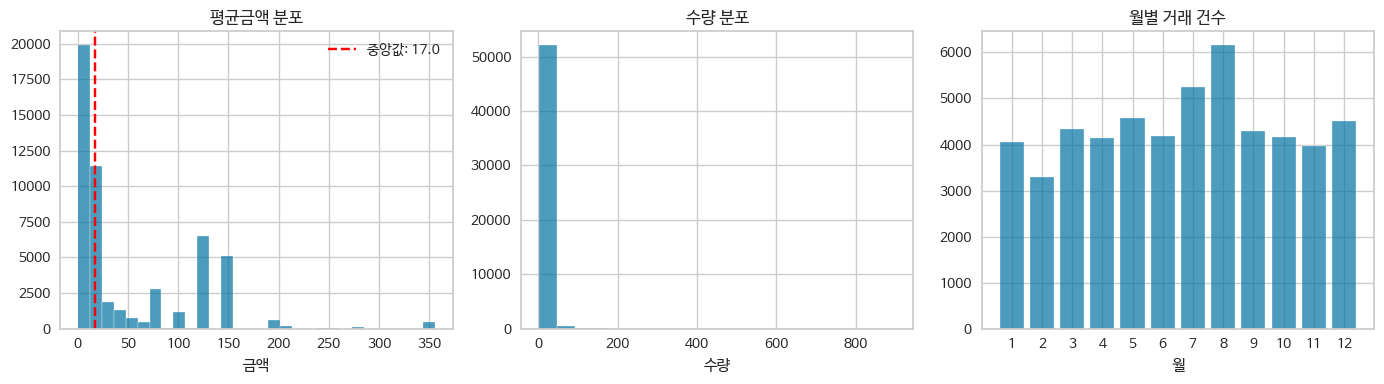

In [83]:
# 주요 변수 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 평균금액 분포
axes[0].hist(online_sales['평균금액'], bins=30, edgecolor='white', alpha=0.7)
axes[0].axvline(online_sales['평균금액'].median(), color='red', linestyle='--',
                label=f'중앙값: {online_sales["평균금액"].median():.1f}')
axes[0].set_title('평균금액 분포')
axes[0].set_xlabel('금액')
axes[0].legend()

# 수량 분포
axes[1].hist(online_sales['수량'], bins=20, edgecolor='white', alpha=0.7)
axes[1].set_title('수량 분포')
axes[1].set_xlabel('수량')

# 월별 거래 건수
monthly = online_sales.groupby(online_sales['거래날짜'].dt.month).size()
axes[2].bar(monthly.index, monthly.values, edgecolor='white', alpha=0.7)
axes[2].set_title('월별 거래 건수')
axes[2].set_xlabel('월')
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

### EDA 결과 요약

- 결측치 없음
- 중복 데이터 존재 -> 전처리 시 제거 필요
- 평균금액, 수량에 이상치 존재하나 비즈니스적으로 유의미한 고액 구매일 수 있으므로 유지
- 월별로 거래량 차이가 있음 -> 시즌성 고려 필요

---
# 2. 데이터 전처리

In [84]:
# 고객ID, 거래날짜, 제품ID, 제품카테고리, 수량, 평균금액, 배송료, 쿠폰상태가 모두 같은 값은 중복값으로 간주하여 제거
online_sales = online_sales.drop_duplicates(subset=['고객ID', '거래날짜', '제품ID', '제품카테고리', '수량', '평균금액', '배송료', '쿠폰상태'], keep='first').reset_index(drop=True)
online_sales['금액'] = online_sales['평균금액']*online_sales['수량']
online_sales['거래날짜'] = pd.to_datetime(online_sales['거래날짜'])
online_sales['월'] = online_sales['거래날짜'].dt.strftime('%b')
online_sales = pd.merge(online_sales, tax, on=['제품카테고리'], how='left')

# 금액에 쿠폰 적용 상태와 할인율, 세금을 적용하여 최종 결제 금액을 계산
online_sales_merge = pd.merge(online_sales, discount, on=['월', '제품카테고리'], how='left')
online_sales_merge['할인된_금액'] = online_sales_merge.apply(lambda row: row['금액'] * (1 - row['할인율'] / 100) if row['쿠폰상태'] == 'Used' else row['금액'], axis=1)
online_sales_merge['판매세'] = online_sales_merge['할인된_금액'] * online_sales_merge['GST']
online_sales_merge['최종결제금액'] = online_sales_merge['할인된_금액'] + online_sales_merge['배송료'] + online_sales_merge['판매세']
online_sales_merge = online_sales_merge.drop(['할인된_금액','판매세'], axis=1)

print(f"전처리 후 데이터 크기: {online_sales_merge.shape[0]:,}행")
online_sales_merge.head()

전처리 후 데이터 크기: 50,228행


,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,금액,월,GST,쿠폰코드,할인율,최종결제금액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,153.71,Jan,0.10,ELEC10,10.0,158.6729
1,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,2.05,Jan,0.10,OFF10,10.0,8.5295
2,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,87.65,Jan,0.18,SALE10,10.0,109.9270
3,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,16.50,Jan,0.18,AIO10,10.0,24.0230
4,USER_1358,Transaction_0003,2019-01-01,Product_0854,Bags,15,5.15,6.5,Used,77.25,Jan,0.18,AIO10,10.0,88.5395


---
# 3. 고객 세분화

고객을 비슷한 특성을 가진 여러 그룹으로 세분화하기 위해 RFM 분석과 K-means 클러스터링 방법을 사용하였다.

## 3-1. RFM 분석

먼저 RFM 분석을 통해 고객별로 Recency, Frequency, Monetary 점수를 계산한다.

In [85]:
rfm_online_sales = online_sales_merge.copy()
rfm_online_sales['거래날짜'] = pd.to_datetime(rfm_online_sales['거래날짜'])

recency_data = rfm_online_sales.groupby('고객ID')['거래날짜'].max().reset_index()
recency_data['Recency'] = (rfm_online_sales['거래날짜'].max() - recency_data['거래날짜']).dt.days

frequency_data = rfm_online_sales.groupby('고객ID')['거래ID'].count().reset_index()
frequency_data.rename(columns={'거래ID': 'Frequency'}, inplace=True)

monetary_data = rfm_online_sales.groupby('고객ID')['최종결제금액'].sum().reset_index()
monetary_data.rename(columns={'최종결제금액': 'Monetary'}, inplace=True)

rfm_data = recency_data.merge(frequency_data, on='고객ID').merge(monetary_data, on='고객ID')
rfm_data.head()

,고객ID,거래날짜,Recency,Frequency,Monetary
0,USER_0000,2019-09-15,107,2,174.98174
1,USER_0001,2019-11-02,59,59,15516.94396
2,USER_0002,2019-10-19,73,23,1689.55594
3,USER_0003,2019-12-14,17,17,1467.43528
4,USER_0004,2019-09-15,107,35,1855.16400


## 3-2. K-means Clustering

### 상관관계 확인

세 변수 사이의 상관관계를 파악한다. Frequency와 Monetary 사이의 상관관계가 0.9 이상으로 매우 높다는 것을 확인할 수 있다. 이는 다중공선성 문제를 발생시킬 수 있으므로, 두 변수 중 Monetary를 제거하기로 한다.

In [86]:
rfm_data[['Recency','Frequency','Monetary']].corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.204631,-0.207642
Frequency,-0.204631,1.000000,0.939217
Monetary,-0.207642,0.939217,1.000000


### 로그 변환

Recency와 Frequency 사이의 분포를 2차원상으로 구해보았다. 매우 치우친 분포 형태이므로 로그변환을 시도한다.

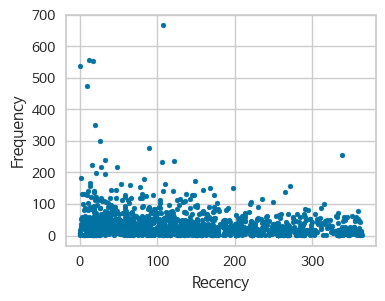

In [87]:
plt.figure(figsize=(4,3))
plt.scatter(rfm_data["Recency"],rfm_data["Frequency"], marker=".")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.show()

로그 변환 후 데이터 형태가 개선된 것을 확인할 수 있다.

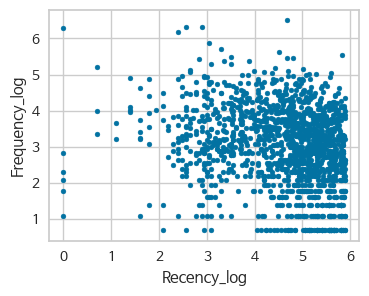

In [88]:
cl_df = rfm_data.copy()
cl_df['Recency_log'] = np.log1p(cl_df['Recency'])
cl_df['Frequency_log'] = np.log1p(cl_df['Frequency'])

plt.figure(figsize=(4,3))
plt.scatter(cl_df["Recency_log"],cl_df["Frequency_log"], marker=".")
plt.xlabel("Recency_log")
plt.ylabel("Frequency_log")
plt.show()

### Clustering

KElbowVisualizer 라이브러리를 활용하여 최적의 cluster 개수를 구한다. 클러스터 6개가 최상의 군집 개수라는 결과가 나온다.

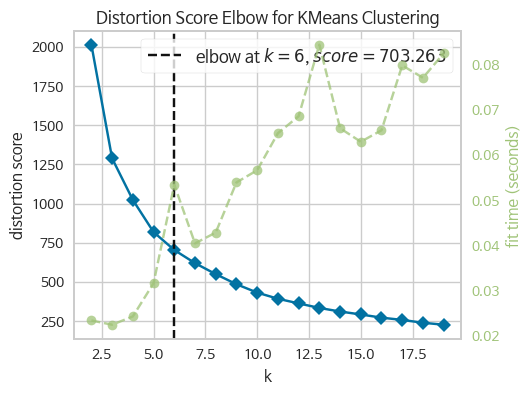

In [89]:
plt.figure(figsize=(5,4))
kmeans = KMeans(random_state=42, n_init=10)
elbow = KElbowVisualizer(kmeans,k=(2,20))
elbow.fit(cl_df[['Recency_log','Frequency_log']].values)
elbow.show()
plt.show()

### 최종

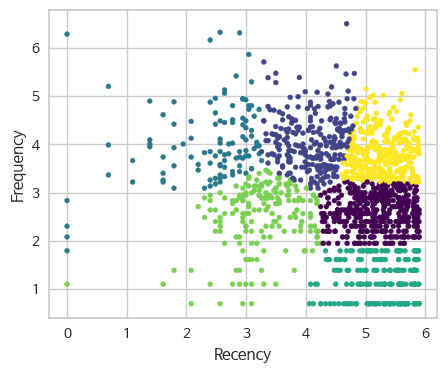

In [91]:
# 정규화 및 Scaling
rfm_val = cl_df[['Recency_log','Frequency_log']].values
rfm_val_scaled = StandardScaler().fit_transform(rfm_val)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster = kmeans.fit_predict(rfm_val_scaled)

# K-means Clustering 시각화
plt.figure(figsize=(5,4))
plt.scatter(cl_df["Recency_log"],cl_df["Frequency_log"], marker=".", c=cluster, cmap='viridis')
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.show()

In [93]:
# 클러스터링 결과
value_mapping = {0: "Cl1", 1: "Cl2", 2: "Cl3", 3: "Cl4", 4: "Cl5", 5: "Cl6"}
cluster2 = np.array([value_mapping[value] for value in cluster])
rfm_data['cluster'] = cluster2
rfm_data.head()

,고객ID,거래날짜,Recency,Frequency,Monetary,cluster
0,USER_0000,2019-09-15,107,2,174.98174,Cl4
1,USER_0001,2019-11-02,59,59,15516.94396,Cl2
2,USER_0002,2019-10-19,73,23,1689.55594,Cl2
3,USER_0003,2019-12-14,17,17,1467.43528,Cl5
4,USER_0004,2019-09-15,107,35,1855.16400,Cl6


각 군집에 포함된 고객의 수는 다음과 같다.

In [94]:
print(rfm_data['cluster'].value_counts().sort_index())

cluster
Cl1    427
Cl2    245
Cl3    107
Cl4    194
Cl5    186
Cl6    309
Name: count, dtype: int64


---
# 4. 클러스터별 특성 분석

In [95]:
df = online_sales_merge.copy()
df["월"] = df['거래날짜'].dt.month
df['month'] = df['거래날짜'].dt.strftime('%b')

# 가입기간을 1년이하, 1년, 2년, 3년이후로 구간화
rfm_data2 = rfm_data.copy()
rfm_data = rfm_data2.merge(customers, on = "고객ID", how = 'left')
rfm_data['가입기간_년'] = pd.cut(rfm_data['가입기간'], bins=[0, 12, 24, 36, 50], labels=['1년이하', '1년', '2년', '3년이후'])
df2 = pd.merge(df, rfm_data[["고객ID","cluster","성별","고객지역","가입기간","가입기간_년"]], on='고객ID', how='left')

# 사용자 데이터
df_temp = df2.copy()
df_temp = pd.merge(df_temp, rfm_data[["고객ID", "Recency", "Frequency", "Monetary"]], on = '고객ID', how = 'left')
df_temp['구매건수'] = df_temp.groupby('고객ID')['고객ID'].transform('size')
df_temp['방문횟수'] = df_temp.groupby('고객ID')['거래날짜'].transform('nunique')
df_user = df_temp.groupby('고객ID').agg({'성별': 'first', '고객지역': 'first', '가입기간' : 'first', '가입기간_년' : 'first',
                                         '구매건수':'first', '방문횟수':'first',  'cluster': 'first'}).reset_index()
# 쿠폰 상태 추가
coupon_state = df_temp.groupby(['고객ID', '쿠폰상태']).size().unstack(fill_value = 0)
coupon_state['Sum'] = coupon_state['Clicked'] + coupon_state['Used'] + coupon_state['Not Used']
coupon_state['Used Ratio'] = coupon_state['Used'] / coupon_state['Sum']
df_user = df_user.merge(coupon_state['Used Ratio'], on = '고객ID', how = 'left')

# 할인율 추가
df_temp['할인율_cat'] = pd.cut(df_temp['할인율'], bins = [0, 10, 20, 30], labels = ['10%', '20%', '30%'])
discount_rate = df_temp.groupby(['고객ID', '할인율_cat']).size().unstack(fill_value = 0)
discount_rate = discount_rate.rename(columns = {'10%': '할인율_10%', '20%': '할인율_20%', '30%': '할인율_30%'})
df_user = df_user.merge(discount_rate, on = '고객ID', how = 'left')
df_user.iloc[:, -3:] = df_user.iloc[:, -3:].astype(int)

df_finance = df_temp.groupby('고객ID').agg({'수량': 'mean', '평균금액': 'mean', '배송료': 'mean', '최종결제금액': 'mean',
                                            'Recency': 'first','Frequency': 'first','Monetary': 'first', 'cluster': 'first'}).reset_index()
clusters = sorted(df2['cluster'].unique())

## 4-1. 클러스터별 정보 확인

### 성별

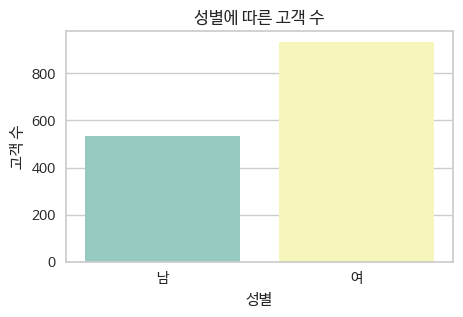

In [96]:
plt.figure(figsize=(5,3))
sns.countplot(x=rfm_data['성별'], palette='Set3', order=sorted(rfm_data['성별'].unique()))
plt.title('성별에 따른 고객 수'); plt.xlabel('성별'); plt.ylabel('고객 수')
plt.show()

- 여성 고객이 남성 고객보다 많다.

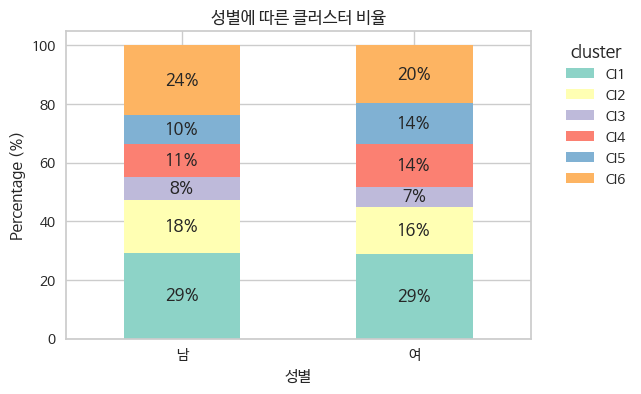

In [97]:
df3 = pd.crosstab(rfm_data['성별'],rfm_data['cluster'])
df3['Total'] = df3.sum(axis=1)
for col in clusters:
    df3[col] = df3[col] / df3['Total'] * 100
df3 = df3.drop('Total', axis=1)

plt.rcParams["figure.figsize"] = (6,4)
color_p = sns.color_palette("Set3",6)
ax = df3.plot(kind='bar', stacked=True, color=color_p)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.0f}%', ha='center', va='center')

plt.xlabel('성별')
plt.ylabel('Percentage (%)')
plt.title('성별에 따른 클러스터 비율')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.show()

- 성별에 따른 클러스터의 비율을 100% 누적 막대 그래프로 확인해 보았다.
- 대체로 성별에 따른 Cluster의 비율은 비슷하다.

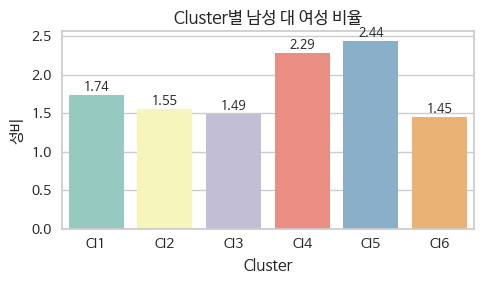

In [98]:
df4 = pd.crosstab(rfm_data['cluster'],rfm_data['성별'])
df4['Total'] = df4.sum(axis=1)
df4['성비'] = df4['여'] / df4['남']

plt.figure(figsize=(5,3))
sns.barplot(x=df4.index, y='성비', data=df4, palette='Set3')

for i in range(len(df4)):
    plt.text(i, df4.iloc[i]['성비'], f"{df4.iloc[i]['성비']:.2f}", ha='center', va='bottom',fontsize= 9)

plt.xlabel('Cluster')
plt.ylabel('성비')
plt.title('Cluster별 남성 대 여성 비율')
plt.tight_layout()
plt.show()

- 남녀 간 성비는 Cluster 4와 Cluster 5에서 1:2를 넘어 가장 차이가 크게 나타난다.
- Cluster 3과 6은 상대적으로 균형 잡힌 성비를 보인다.

### 지역

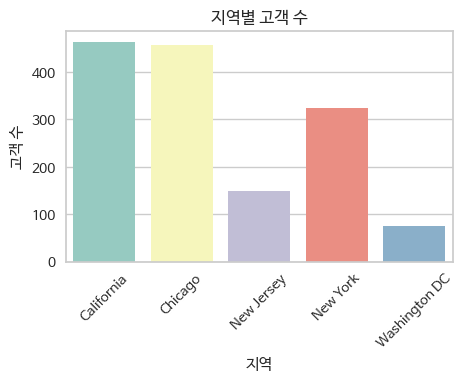

In [27]:
plt.figure(figsize=(5,3))
sns.countplot(x=rfm_data['고객지역'], palette='Set3', order=sorted(rfm_data['고객지역'].unique()))
plt.title('지역별 고객 수'); plt.xlabel('지역'); plt.ylabel('고객 수'); plt.xticks(rotation=45)
plt.show()

- 고객들이 거주하는 지역은 California, Chicago, New York, New Jersey, Washington DC 순으로 많다.

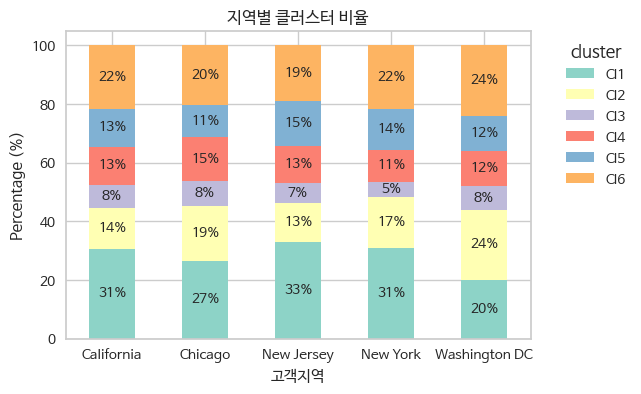

In [28]:
df3 = pd.crosstab(rfm_data['고객지역'],rfm_data['cluster'])
df3['Total'] = df3.sum(axis=1)
for col in clusters:
    df3[col] = df3[col] / df3['Total'] * 100
df3 = df3.drop('Total', axis=1)

plt.rcParams["figure.figsize"] = (6,4)
color_p = sns.color_palette("Set3")
ax = df3.plot(kind='bar', stacked=True, color=color_p)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.0f}%', ha='center', va='center', fontsize=10)

plt.xlabel('고객지역')
plt.ylabel('Percentage (%)')
plt.title('지역별 클러스터 비율')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.show()

- California, Chicago, New York, New Jersey, Washington DC 순으로 고객이 많다.
- New Jersey의 경우 Cluster 1의 비중이, Washington DC의 경우 Cluster 6의 비중이 높게 나타났다.

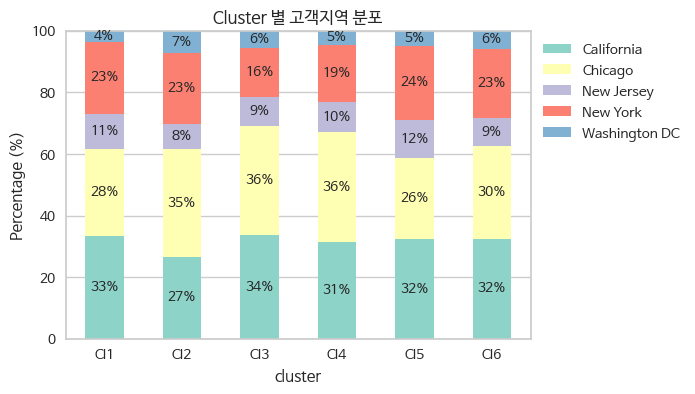

In [29]:
area_pivot = pd.crosstab(rfm_data['cluster'], rfm_data['고객지역'])
area_total = area_pivot.sum(axis=1)
area_pivot2 = area_pivot.div(area_total, axis=0)

ax = area_pivot2.plot(kind='bar', stacked=True, color=sns.color_palette('Set3'), figsize=(6,4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, '{:.0%}'.format(height), ha='center', va='center', fontsize=10)

plt.title('Cluster 별 고객지역 분포')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=0); plt.ylabel('Percentage (%)')
plt.gca().set_yticklabels(['{:.0f}'.format(x*100) for x in plt.gca().get_yticks()])
plt.ylim(0, 1)
plt.show()

- 각 Cluster에 따른 고객들의 지역의 분포는 위와 같다.

### 가입기간

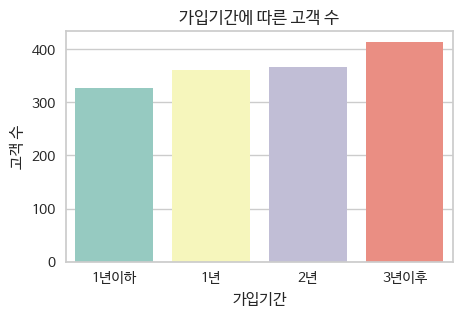

In [30]:
plt.figure(figsize=(5,3))
sns.countplot(x=rfm_data['가입기간_년'], palette='Set3')
plt.title('가입기간에 따른 고객 수'); plt.xlabel('가입기간'); plt.ylabel('고객 수')
plt.show()

- 가입기간이 길수록 고객의 수가 많다.

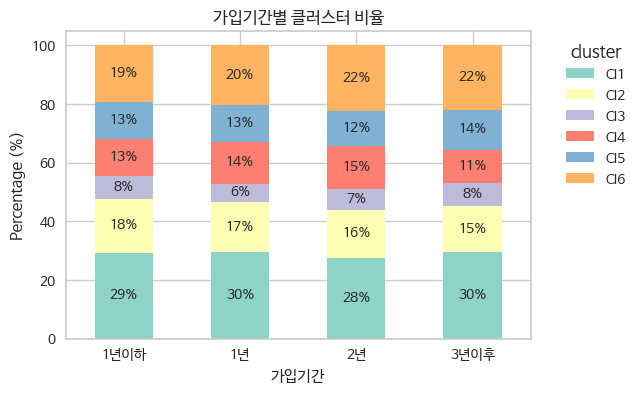

In [31]:
df3 = pd.crosstab(rfm_data['가입기간_년'],rfm_data['cluster'])
df3['Total'] = df3.sum(axis=1)
for col in clusters:
    df3[col] = df3[col] / df3['Total'] * 100
df3 = df3.drop('Total', axis=1)

plt.rcParams["figure.figsize"] = (6,4)
color_p = sns.color_palette("Set3")
ax = df3.plot(kind='bar', stacked=True, color=color_p)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.0f}%', ha='center', va='center', fontsize=10)

plt.xlabel('가입기간')
plt.ylabel('Percentage (%)')
plt.title('가입기간별 클러스터 비율')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.show()

- Cluster 별로 가입기간의 비율은 대체로 비슷하다.
- 가입기간이 3년 이후인 경우 Cluster 6의 비율이 상대적으로 많다.

### 수량

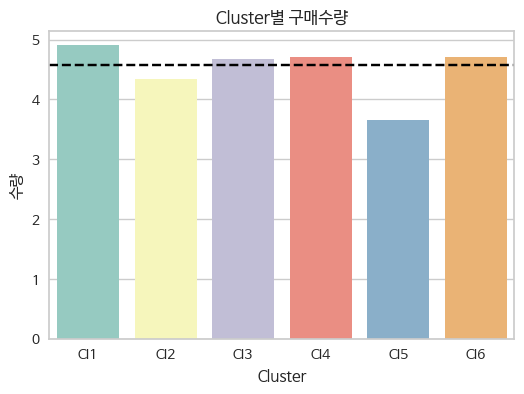

In [32]:
amount_pivot = df_finance.groupby(['cluster'])['수량'].mean()
amount_pivot['평균'] = df_finance['수량'].mean()

plt.figure(figsize = (6,4))
sns.barplot(x = df_finance['cluster'], y = df_finance['수량'], order = clusters, palette = 'Set3', ci=None)
plt.axhline(y = amount_pivot['평균'], color = 'black', linestyle = '--')
plt.title('Cluster별 구매수량')
plt.xlabel("Cluster")
plt.show()

- Cluster 5에서 구매하는 수량이 상대적으로 적게 나타난다.

### 평균금액/최종결제금액

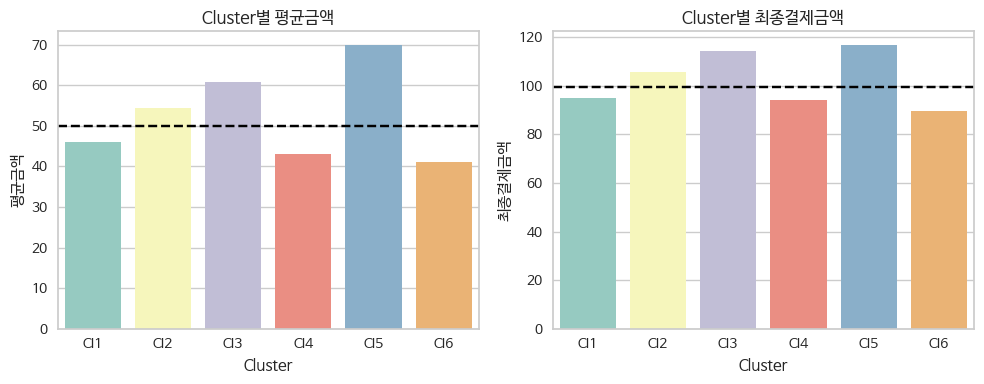

In [33]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
average_pivot = df_finance.groupby(['cluster'])['평균금액'].mean()
average_pivot['평균'] = df_finance['평균금액'].mean()
sns.barplot(x=df_finance['cluster'], y=df_finance['평균금액'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=average_pivot['평균'], color='black', linestyle='--')
plt.title('Cluster별 평균금액')
plt.xlabel("Cluster")

plt.subplot(1, 2, 2)
final_pivot = df_finance.groupby(['cluster'])['최종결제금액'].mean()
final_pivot['평균'] = df_finance['최종결제금액'].mean()
sns.barplot(x=df_finance['cluster'], y=df_finance['최종결제금액'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=final_pivot['평균'], color='black', linestyle='--')
plt.title('Cluster별 최종결제금액')
plt.xlabel("Cluster")

plt.tight_layout()
plt.show()

- Cluster별로 사용하는 평균 금액은 Cluster 5가 가장 높고, Cluster 4와 6이 낮다.
- 최종결제금액은 Cluster 5 > Cluster 3 > Cluster 1 > Cluster 2 > Cluster 4 > Cluster 6 순으로 높게 나타난다.

### 배송료

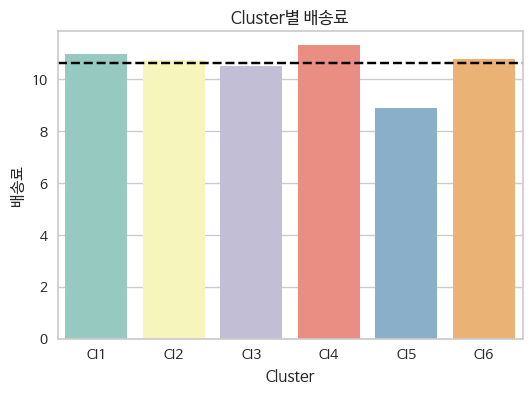

In [34]:
deliver_pivot = df_finance.groupby(['cluster'])['배송료'].mean()
deliver_pivot['평균'] = df_finance['배송료'].mean()

plt.figure(figsize = (6,4))
sns.barplot(x = df_finance['cluster'], y = df_finance['배송료'], palette = 'Set3', order=clusters, ci=None)
plt.axhline(y = df_finance['배송료'].mean(), color = 'black', linestyle = '--')
plt.title('Cluster별 배송료')
plt.xlabel("Cluster")
plt.show()

- Cluster별 평균 배송료는 Cluster 4가 높고, Cluster 5가 낮다.

### 쿠폰사용비율

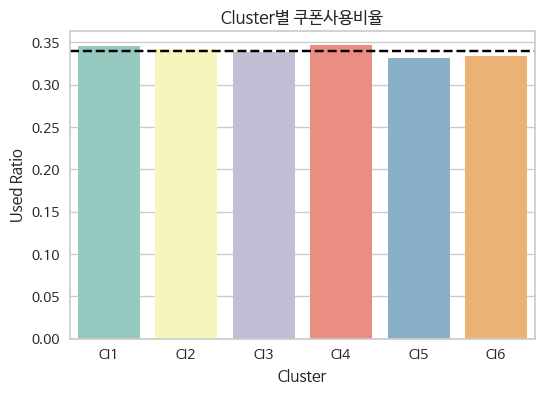

In [35]:
coupon_pivot = df_user.groupby('cluster')['Used Ratio'].mean()

plt.figure(figsize = (6,4))
sns.barplot(x = coupon_pivot.index, y = coupon_pivot, palette = 'Set3')
plt.axhline(y = coupon_pivot.mean(), color = 'black', linestyle = '--')
plt.title('Cluster별 쿠폰사용비율')
plt.xlabel("Cluster")
plt.show()

- 쿠폰 사용률은 Cluster별로 큰 차이가 없다.
- Cluster 1과 4가 쿠폰을 조금 더 적극적으로 사용하는 경향을 보인다.

### 할인쿠폰 분포

<Figure size 600x400 with 0 Axes>

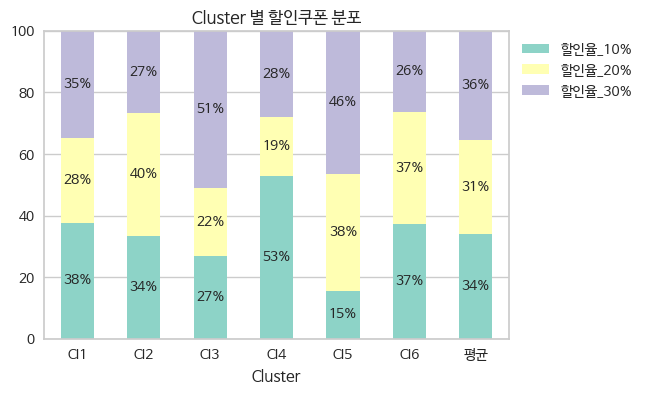

In [36]:
discount_pivot = df_user.groupby('cluster')[['할인율_10%', '할인율_20%', '할인율_30%']].mean()
discount_total = discount_pivot.sum(axis=1)
discount_pivot2 = discount_pivot.div(discount_total, axis=0)
discount_pivot2.loc['평균'] = discount_pivot2.mean(axis=0)

plt.figure(figsize=(6, 4))
ax = discount_pivot2.plot(kind='bar', stacked=True, color=sns.color_palette('Set3'), figsize=(6, 4))
plt.title('Cluster 별 할인쿠폰 분포')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Cluster")
plt.xticks(rotation=0)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, '{:.0%}'.format(height), ha='center', va='center', fontsize=10)

plt.gca().set_yticklabels(['{:.0f}'.format(x*100) for x in plt.gca().get_yticks()])
plt.ylim(0, 1)
plt.show()

- Cluster 3에서는 30% 할인쿠폰을, Cluster 4에서는 10% 할인쿠폰을 절반 이상이 사용하였다.
- Cluster 2, 6은 큰 차이 없이 골고루 할인쿠폰을 사용하였다.

### 구매건수/방문횟수

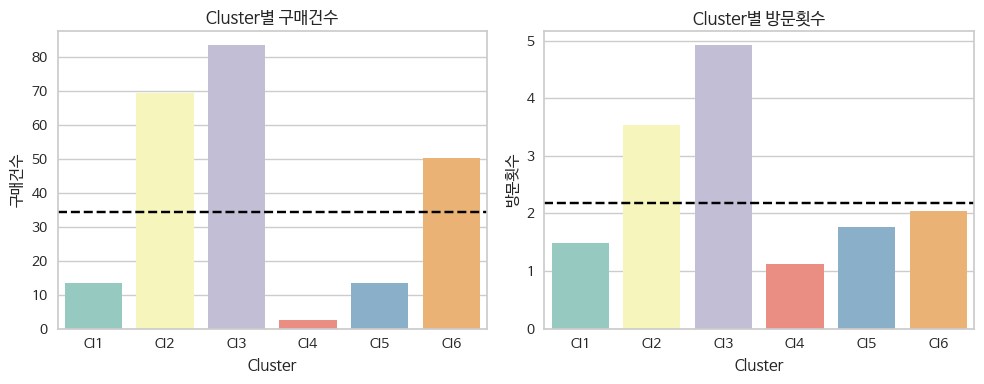

In [37]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(x=df_user['cluster'], y=df_user['구매건수'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=df_user['구매건수'].mean(), color='black', linestyle='--')
plt.title('Cluster별 구매건수')
plt.xlabel("Cluster")

plt.subplot(1, 2, 2)
sns.barplot(x=df_user['cluster'], y=df_user['방문횟수'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=df_user['방문횟수'].mean(), color='black', linestyle='--')
plt.title('Cluster별 방문횟수')
plt.xlabel("Cluster")

plt.tight_layout()
plt.show()

- Cluster 별 구매건수는 Cluster 3이 가장 높았고, Cluster 2, Cluster 6이 그 뒤를 이었으며 나머지 클러스터는 상대적으로 낮게 나타났다.
- 방문 횟수는 Cluster 3, 2, 6이 가장 높았으며 나머지 클러스터는 상대적으로 낮게 나타났다.

### R, F, M score

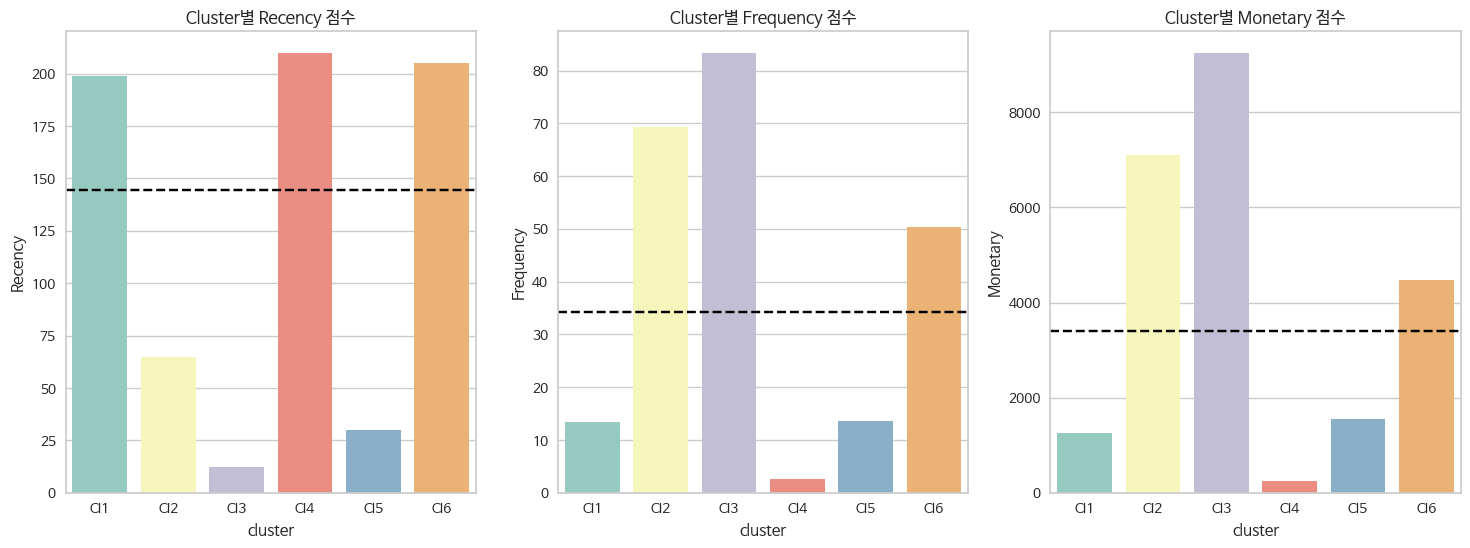

In [38]:
plt.figure(figsize=(18,6))
plt.subplot(1, 3, 1)
sns.barplot(x=df_finance['cluster'], y=df_finance['Recency'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=df_finance['Recency'].mean(), color='black', linestyle='--')
plt.title('Cluster별 Recency 점수')

plt.subplot(1, 3, 2)
sns.barplot(x=df_finance['cluster'], y=df_finance['Frequency'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=df_finance['Frequency'].mean(), color='black', linestyle='--')
plt.title('Cluster별 Frequency 점수')

plt.subplot(1, 3, 3)
sns.barplot(x=df_finance['cluster'], y=df_finance['Monetary'], order=clusters, palette='Set3', ci=None)
plt.axhline(y=df_finance['Monetary'].mean(), color='black', linestyle='--')
plt.title('Cluster별 Monetary 점수')
plt.show()

- Cluster 1: R 높고 F/M 낮음
- Cluster 2: R 낮고 F/M 높음
- Cluster 3: R 매우낮고 F/M 매우높음
- Cluster 4: R 매우높고 F/M 매우낮음
- Cluster 5: R 낮고 F/M 낮음
- Cluster 6: R 높고 F/M 높음

### 월 (거래날짜)

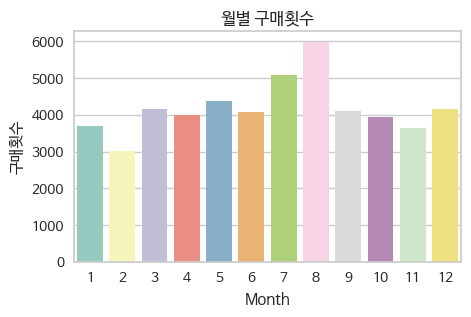

In [39]:
plt.figure(figsize=(5,3))
sns.countplot(x=df['월'], palette='Set3')
plt.title('월별 구매횟수'); plt.xlabel('Month'); plt.ylabel('구매횟수')
plt.show()

- 고객들은 7,8월에 가장 많이 구매했고, 2월에는 상대적으로 적게 구매했다.

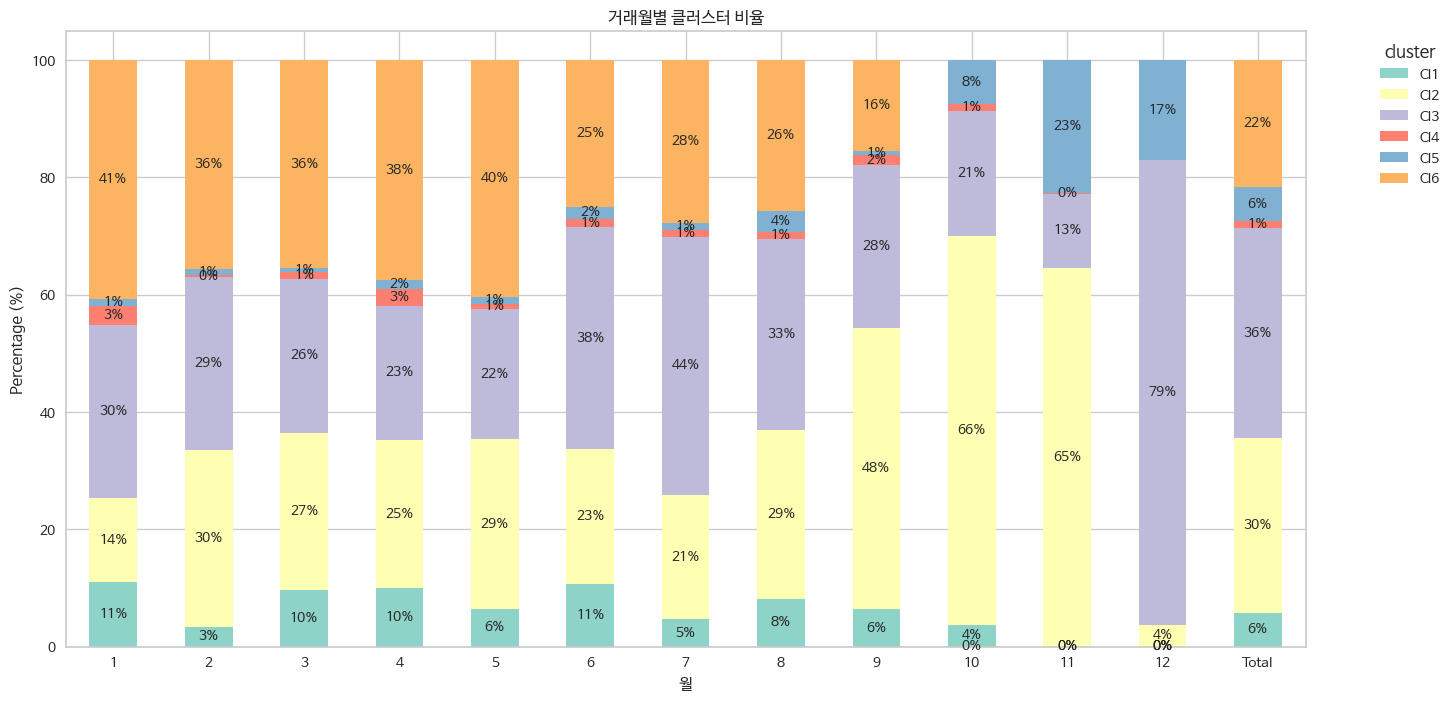

In [40]:
dat2 = df.pivot_table(index='고객ID', columns='월', aggfunc='size', fill_value=0).reset_index()
dat2['Total'] = dat2.iloc[:, 1:13].sum(axis=1)
dat2 = pd.merge(dat2, rfm_data[["고객ID","cluster"]], on='고객ID', how='left')

num_cols = dat2.iloc[:, 1:14].columns.values.tolist()
summary_dfs = []
for col in num_cols:
    summary = dat2.groupby('cluster')[col].mean()
    summary_dfs.append(summary)

summary_df = pd.concat(summary_dfs, axis=1)
df_group_total = summary_df.T.copy()
df_group_total['Total'] = df_group_total.sum(axis=1)
for col in clusters:
    df_group_total[col] = df_group_total[col] / df_group_total['Total'] * 100

plt.rcParams["figure.figsize"] = (16,8)
color_p = sns.color_palette("Set3")
df_group_100 = df_group_total.drop('Total', axis=1)
ax = df_group_100.plot(kind='bar', stacked=True, color=color_p)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.0f}%', ha='center', va='center', fontsize=10)

plt.xlabel('월')
plt.ylabel('Percentage (%)')
plt.title('거래월별 클러스터 비율')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

- Cl1은 하반기로 갈수록 구매를 하지 않는다.
- Cl2는 9~11월에 구매율이 높다.
- Cl3는 12월에 집중적으로 구매한다.
- Cl5는 11월에 구매율이 높다.
- Cl6은 상반기에 구매를 많이 하지만 하반기에 구매를 하지 않는다.

### 제품카테고리

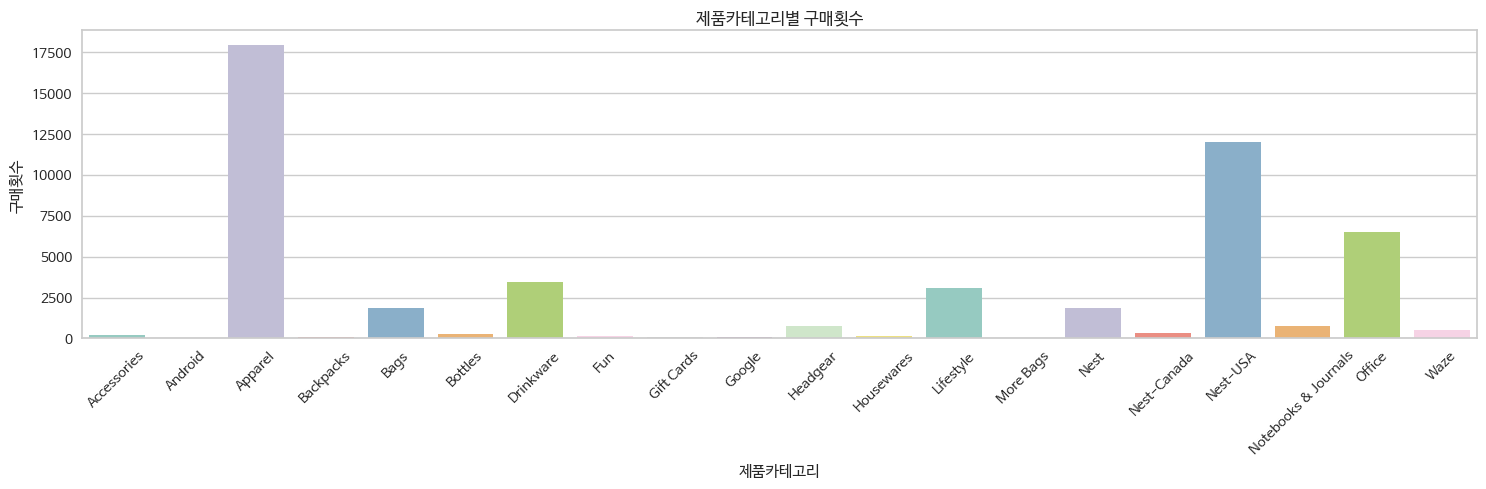

In [41]:
plt.figure(figsize=(18,4))
sns.countplot(x=df['제품카테고리'], palette='Set3', order=sorted(df['제품카테고리'].unique()))
plt.title('제품카테고리별 구매횟수'); plt.xlabel('제품카테고리'); plt.ylabel('구매횟수'); plt.xticks(rotation=45)
plt.show()

- 고객들은 Apparel, Nest-USA, Office 등의 제품을 많이 구매했다.

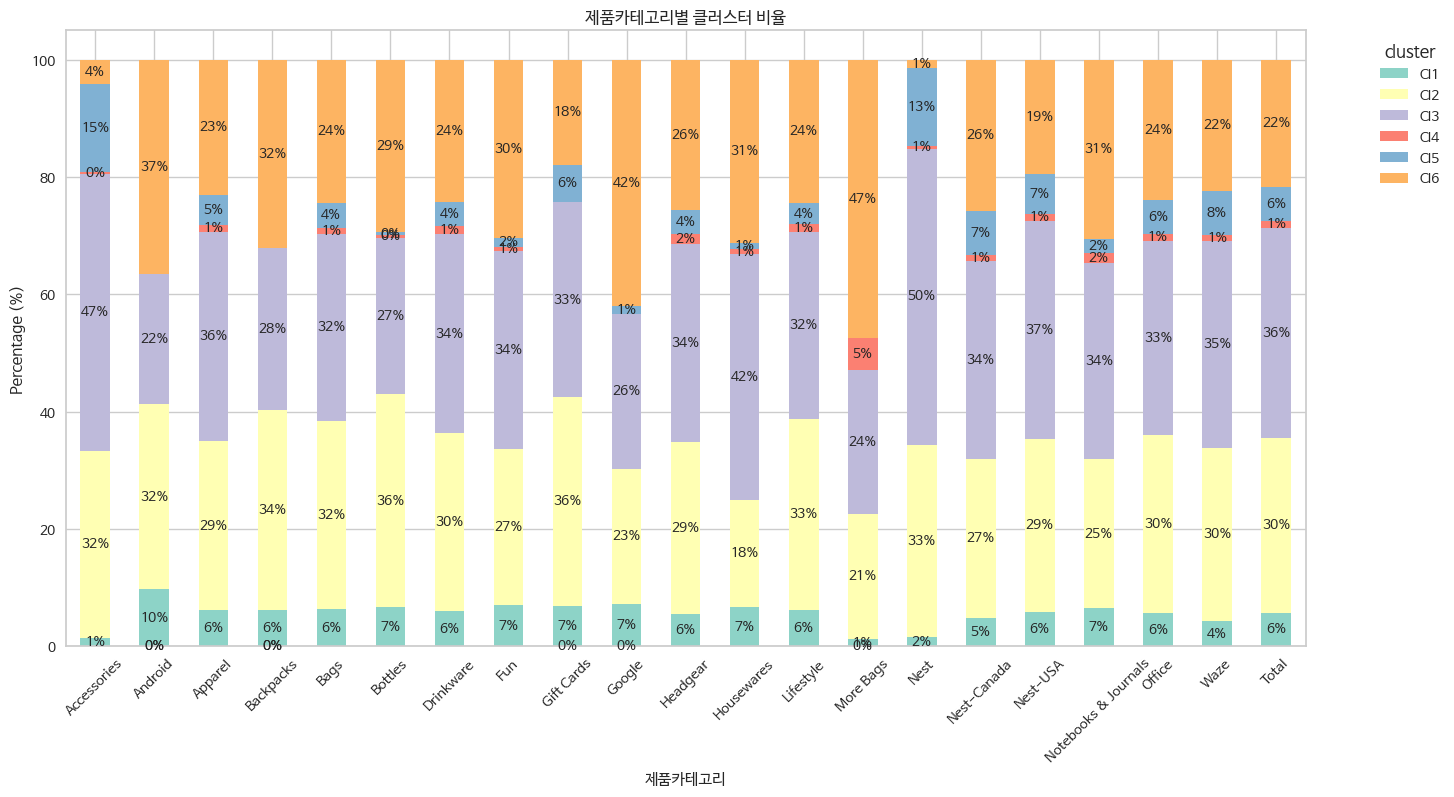

In [42]:
dat2 = df2.pivot_table(index='고객ID', columns='제품카테고리', aggfunc='size', fill_value=0).reset_index()
dat2['Total'] = dat2.iloc[:, 1:21].sum(axis=1)
dat2 = pd.merge(dat2, rfm_data[["고객ID","cluster"]], on='고객ID', how='left')

num_cols = dat2.iloc[:, 1:22].columns.values.tolist()
summary_dfs = []
for col in num_cols:
    summary = dat2.groupby('cluster')[col].mean()
    summary_dfs.append(summary)

summary_df = pd.concat(summary_dfs, axis=1)
df_group_total = summary_df.T.copy()
df_group_total['Total'] = df_group_total.sum(axis=1)
for col in clusters:
    df_group_total[col] = df_group_total[col] / df_group_total['Total'] * 100

plt.rcParams["figure.figsize"] = (16,8)
color_p = sns.color_palette("Set3")
df_group_100 = df_group_total.drop('Total', axis=1)
ax = df_group_100.plot(kind='bar', stacked=True, color=color_p)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.0f}%', ha='center', va='center', fontsize=10)

plt.xlabel('제품카테고리')
plt.ylabel('Percentage (%)')
plt.title('제품카테고리별 클러스터 비율')
plt.legend(title='cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

- Cl2는 제품별로 구매 비율이 대체로 비슷하다.
- Cl3는 Accessories, Housewares, Nest 관련 제품을 많이 구매한다.
- Cl5는 Accessories, Nest 제품을 많이 구매한다.
- Cl6은 Android, Google, More Bags 등의 제품을 많이 구매한다.

## 4-2. 마케팅비용

In [43]:
df4 = df2.groupby('거래날짜')['최종결제금액'].sum().reset_index()
marketing1 = marketing.copy()
df4 = pd.concat([df4, marketing1], axis = 1)
df4["마케팅_총비용"] = df4["오프라인비용"] + df4["온라인비용"]
df4 = df4.drop('날짜',axis=1)
df4['거래날짜'] = pd.to_datetime(df4['거래날짜'])
df4['월'] = df4['거래날짜'].dt.month

### 월별 마케팅비용

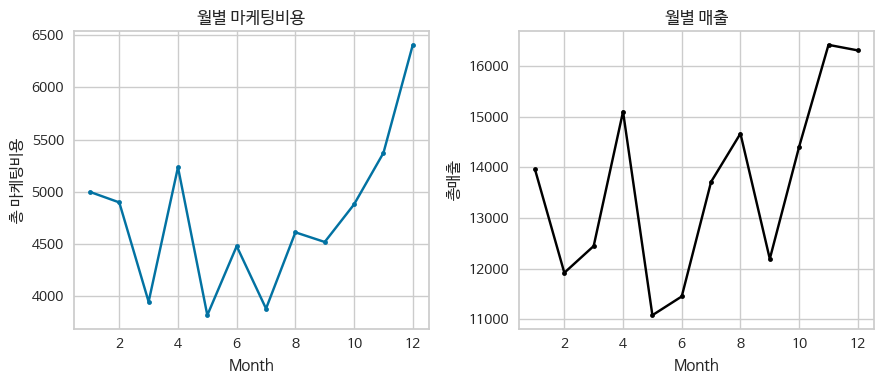

In [44]:
plt.figure(figsize=(9,4))
plt.subplot(1, 2, 1)
df5 = df4.groupby('월')['마케팅_총비용'].mean()
plt.plot(df5.index, df5, marker='.')
plt.title('월별 마케팅비용')
plt.xlabel('Month')
plt.ylabel('총 마케팅비용')

plt.subplot(1, 2, 2)
df6 = df4.groupby('월')['최종결제금액'].mean()
plt.plot(df6.index, df6, marker='.', color='black')
plt.title('월별 매출')
plt.xlabel('Month')
plt.ylabel('총매출')
plt.tight_layout()
plt.show()

- 연말로 갈수록 마케팅비용이 증가하고, 특히 12월에 가장 많은 마케팅비용을 사용한다.
- 여름에는 마케팅비용을 상대적으로 적게 사용한다.
- 7월과 8월의 매출이 가장 높은 것으로 보아 상반기에는 적은 마케팅비용으로 고효율의 매출을 이루었다고 볼 수 있다.

### 마케팅 vs 매출

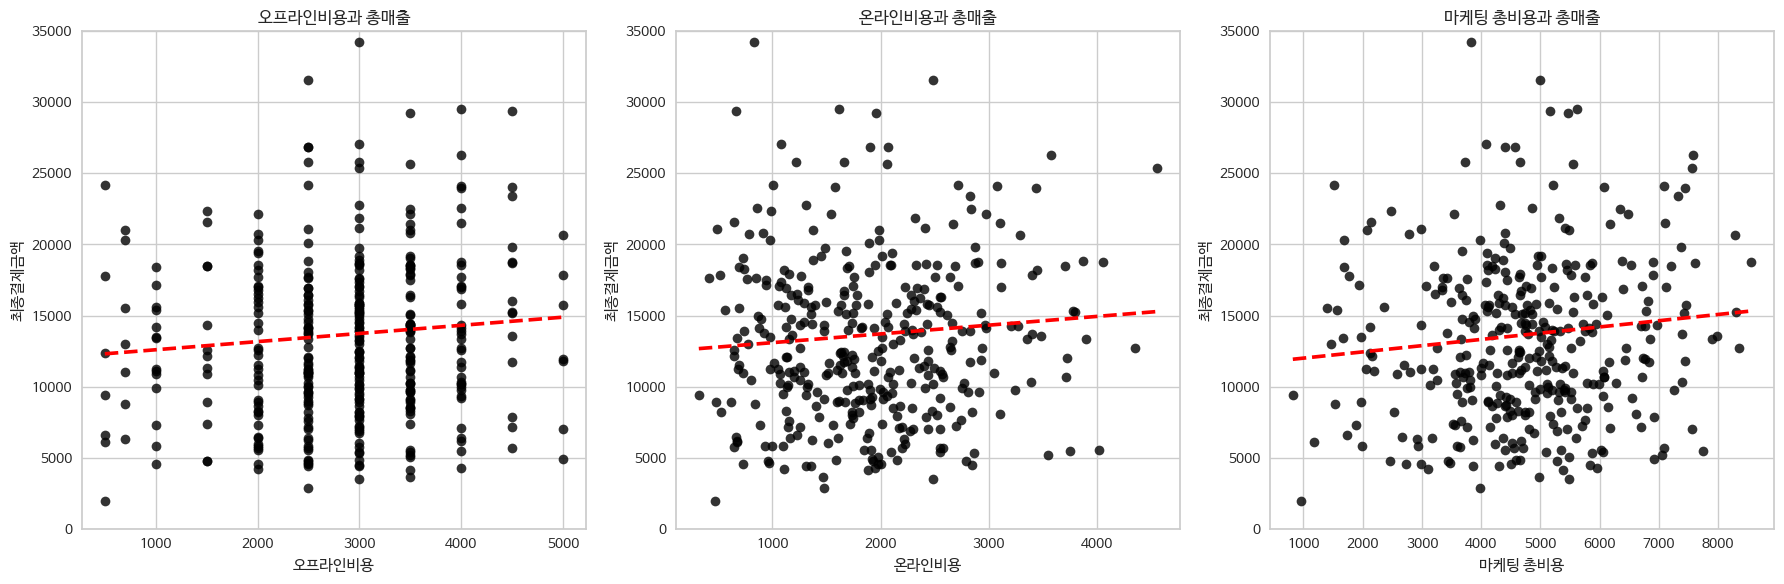

In [45]:
plt.figure(figsize=(18,6))
plt.subplot(1, 3, 1)
sns.regplot(data=df4, x='오프라인비용', y='최종결제금액', color='black', line_kws={'color':'red','linestyle':'--'}, ci=None)
plt.ylim(0,35000)
plt.title('오프라인비용과 총매출')

plt.subplot(1, 3, 2)
sns.regplot(data=df4, x='온라인비용', y='최종결제금액', color='black', line_kws={'color':'red','linestyle':'--'}, ci=None)
plt.ylim(0,35000)
plt.title('온라인비용과 총매출')

plt.subplot(1, 3, 3)
sns.regplot(data=df4, x='마케팅_총비용', y='최종결제금액', color='black', line_kws={'color':'red','linestyle':'--'}, ci=None)
plt.xlabel('마케팅 총비용')
plt.ylim(0,35000)
plt.title('마케팅 총비용과 총매출')
plt.tight_layout()
plt.show()

- 오프라인, 온라인, Total 모두 마케팅비용이 증가할수록 매출도 증가하는 경향을 보인다.


## 4-3. 구매 주기

In [46]:
result = []
for customer_id, group in df.groupby('고객ID'):
    unique_purchase_dates = group['거래날짜'].unique()
    sorted_dates = pd.Series(unique_purchase_dates).sort_values()
    purchase_gaps = sorted_dates.diff().dt.days.dropna()
    avg_purchase_gap = purchase_gaps.mean()
    result.append({'고객ID': customer_id, '구매주기': avg_purchase_gap})

result_df = pd.DataFrame(result)
result_df = result_df.fillna(365)

unique_values = df2.drop_duplicates(subset=['고객ID', '성별', '고객지역',])
unique_values = unique_values[['고객ID', '성별', '고객지역']]
unique_values = pd.merge(unique_values, result_df, how = 'left',on = ("고객ID"))
unique_values = pd.merge(unique_values, rfm_data[['고객ID', 'cluster']], how = 'left',on ="고객ID")

### 성별

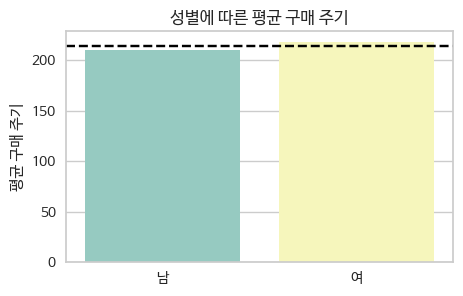

In [47]:
plt.figure(figsize=(5,3))
sns.barplot(data = unique_values.groupby('성별')['구매주기'].mean().reset_index(), x='성별', y='구매주기', palette='Set3')
plt.title(x = 0.5, label='성별에 따른 평균 구매 주기')
plt.axhline(y = unique_values.groupby('성별')['구매주기'].mean().mean(), color = 'black', linestyle = '--')
plt.xlabel('')
plt.ylabel('평균 구매 주기')
plt.show()

- 성별에 따른 구매 주기에는 큰 차이가 없다.

### 지역

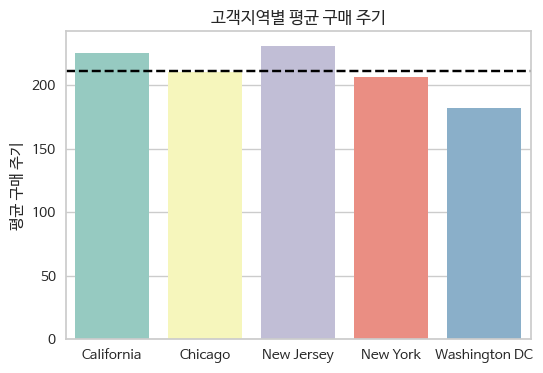

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(data = unique_values.groupby('고객지역')['구매주기'].mean().reset_index(), x='고객지역', y='구매주기', palette='Set3')
plt.title(x = 0.5, label='고객지역별 평균 구매 주기')
plt.axhline(y = unique_values.groupby('고객지역')['구매주기'].mean().mean(), color = 'black', linestyle = '--')
plt.xlabel('')
plt.ylabel('평균 구매 주기')
plt.show()

- Washington DC 지역의 구매 주기가 가장 짧다
- New York, Chicago. California, New Jersey 순으로 구매 주기가 긴 편이다.

### cluster

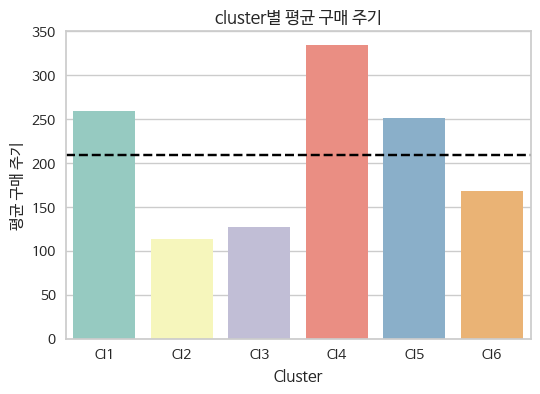

In [49]:
plt.figure(figsize=(6,4))
sns.barplot(data = unique_values.groupby('cluster')['구매주기'].mean().reset_index(), x='cluster', y='구매주기', palette='Set3')
plt.title(x = 0.5, label='cluster별 평균 구매 주기')
plt.axhline(y = unique_values.groupby('cluster')['구매주기'].mean().mean(), color = 'black', linestyle = '--')
plt.xlabel('Cluster')
plt.ylabel('평균 구매 주기')
plt.show()

- Cl4의 구매 주기가 가장 길고,  Cl1, Cl5의 구매 주기도 평균 이상이다.
- Cl6, Cl3, Cl2 의 경우는 구매 주기가 평균 이하로, 짧은 간격으로 구매를 자주 한다는 것을 알 수 있다.

---
# 5. Cohort 분석

In [50]:
ch_data = df2[['고객ID','거래날짜','최종결제금액','고객지역','성별']]
ch_data['거래날짜'] = pd.to_datetime(ch_data['거래날짜'], errors='coerce')
ch_data['거래월'] = ch_data['거래날짜'].dt.strftime('%Y.%m')

first_order = ch_data.groupby('고객ID').거래날짜.min()
first_order = first_order.dt.strftime('%Y.%m')

ch_data = ch_data.set_index('고객ID')
ch_data['FirstOrder'] = first_order
ch_data.reset_index(inplace = True)

first_order_day = ch_data.groupby('고객ID').거래날짜.min().rename('첫구매일')
ch_first= pd.merge(ch_data, first_order_day, on = '고객ID', how = 'left')

ch_first['거래날짜'] = pd.to_datetime(ch_first['거래날짜'], errors='coerce')
ch_first['FirstOrder'] = pd.to_datetime(ch_first['FirstOrder'], errors='coerce')
month_diff = ch_first['거래날짜'].dt.month - ch_first['FirstOrder'].dt.month
ch_first['cohortindex'] = month_diff

## 5-1. 전체 Cohort 분석
### 재구매 시간 간격

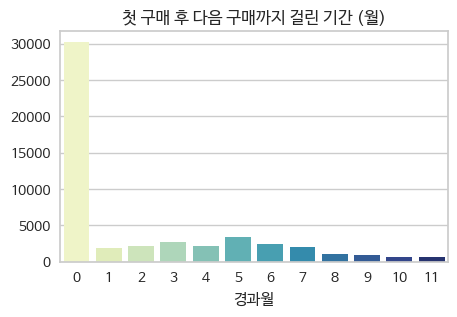

In [51]:
plt.figure(figsize = (5,3))
sns.countplot(data = ch_first, x = "cohortindex", palette = 'YlGnBu')
plt.title(x=0.5, label='첫 구매 후 다음 구매까지 걸린 기간 (월)')
plt.xlabel("경과월")
plt.ylabel("")
plt.show()

- 한 번만 주문한 고객이 가장 많고, 그다음으로 첫 주문으로부터 5개월 후에 주문한 사람이 많다.

### 고객 유지 빈도

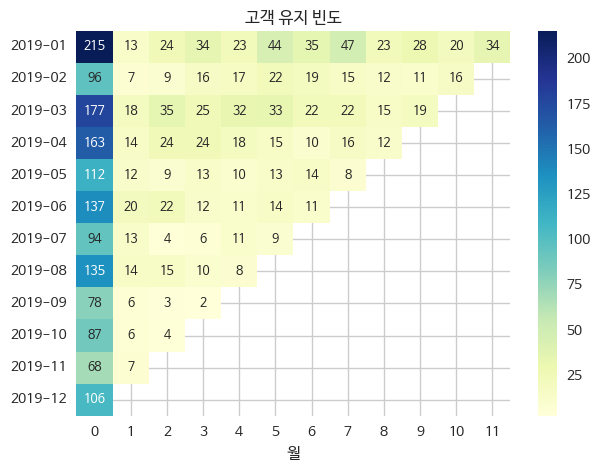

In [52]:
ch_first['첫거래달'] = ch_first['FirstOrder'].astype(str).str[:7]
cohort_count = ch_first.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()

plt.figure(figsize = (7,5))
sns.heatmap(cohort_count, cmap = 'YlGnBu', annot = True, fmt = ".0f", annot_kws={"fontsize":9})
plt.xlabel('월')
plt.ylabel('')
plt.title(x=0.5, label='고객 유지 빈도')
plt.show()

- 고객 유지 빈도는 첫 구매 후 얼마나 많은 고객이 남아있는지 확인할 수 있는 지표이다.  
- 첫 번째 열을 통해 월별로 처음 구매한 고객 수를 확인할 수 있다.

### 월별 신규 유입 고객수

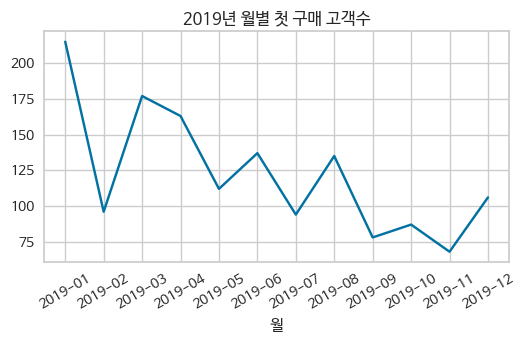

In [53]:
plt.figure(figsize=(6,3))
sns.lineplot(data=cohort_count[0], palette='YlGnBu')
plt.xticks(rotation=30)
plt.title(x=0.5,label='2019년 월별 첫 구매 고객수')
plt.xlabel("월")
plt.ylabel("")
plt.show()

- 3, 6, 8, 12월에 신규 구매한 고객수가 증가한다.

### 고객 유지율

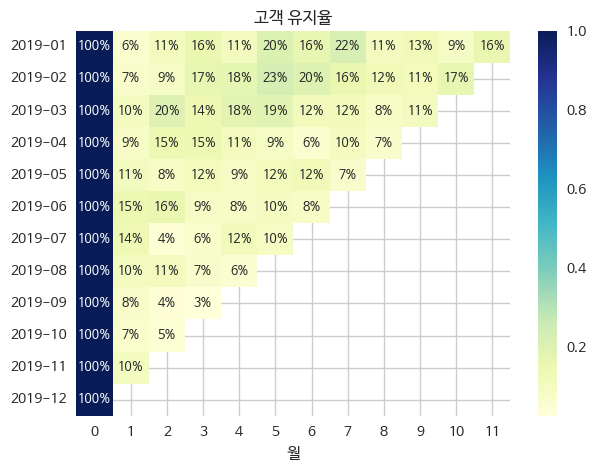

In [54]:
cohort_norm = cohort_count.div(cohort_count[0], axis = 0)
plt.figure(figsize = (7,5))
sns.heatmap(cohort_norm, cmap = 'YlGnBu', annot = True, fmt = '.0%', annot_kws={"fontsize":9})
plt.xlabel('월')
plt.ylabel('')
plt.title(x=0.5, label='고객 유지율')
plt.show()

- 6,7,8월에 고객 유지율이 증가한다.



###  평균 고객 유지율

In [55]:
def get_diagonals(matrix):
    n = len(matrix)
    diagonals = []
    for offset in range(-(n-1), n):
        diagonal = np.diagonal(matrix, offset=offset)
        diagonals.append(diagonal)
    return diagonals

def average_diagonals(matrix):
    diagonals = get_diagonals(matrix)
    avg_diagonals = []
    for diagonal in diagonals:
        avg_diagonal = np.nanmean(diagonal)
        avg_diagonals.append(avg_diagonal)
    return avg_diagonals

avg_diagonals = average_diagonals(np.flipud(cohort_norm.iloc[:, 1:]))
diag_mean = pd.DataFrame({"고객 유지율 평균": avg_diagonals})
diag_mean = diag_mean.dropna()

new_index = range(2, 13)
diag_mean.index = new_index
diag_mean.reset_index(inplace=True)

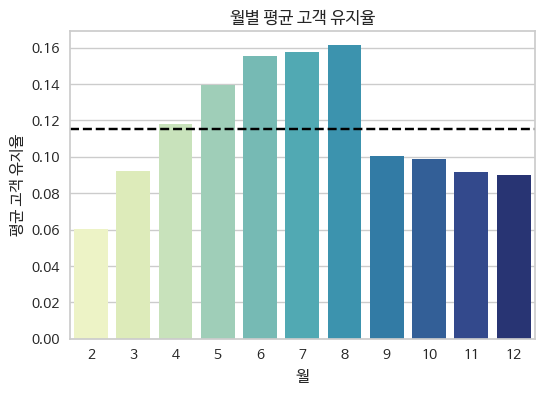

In [56]:
plt.figure(figsize=(6,4))
sns.barplot(data = diag_mean, x = 'index', y='고객 유지율 평균', palette='YlGnBu')
plt.title(x = 0.5, label='월별 평균 고객 유지율')
plt.axhline(y = diag_mean["고객 유지율 평균"].mean(), color = 'black', linestyle = '--')
plt.xlabel('월')
plt.ylabel('평균 고객 유지율')
plt.show()

- 5~8월에 평균 고객 유지율이 높고, 하반기의 경우 고객 유지율은 평균보다 낮다.

### 매출액

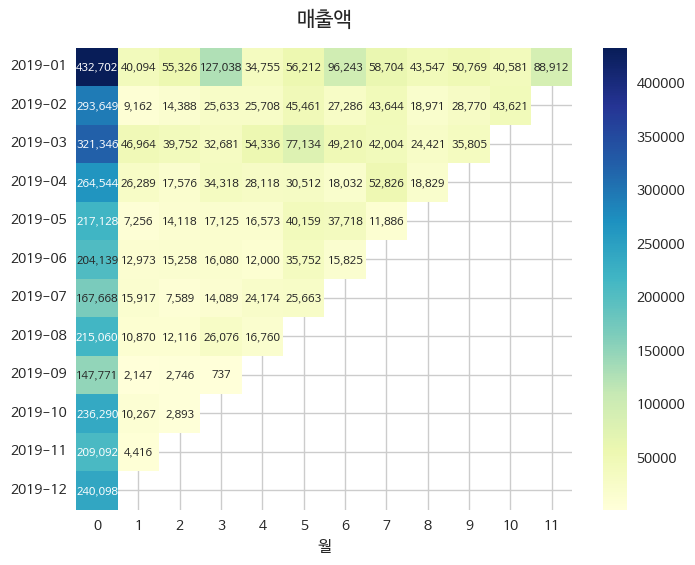

In [57]:
cohort_total_price = ch_first.groupby(["첫거래달","cohortindex"])["최종결제금액"].sum().unstack()
plt.figure(figsize = (8,6))
sns.heatmap(cohort_total_price, cmap = 'YlGnBu', annot = True, fmt = ",.0f", annot_kws={"fontsize":8})
plt.xlabel('월')
plt.ylabel('')
plt.title(x=0.5, y= 1.03, label='매출액',fontsize= 15)
plt.show()

## 5-2. 군집별 Cohort 분석

클러스터별 고객 유지율과 매출액을 구하고, 6개의 클러스터별로 구체적인 특징을 확인한다.

In [58]:
ch_cl = ch_first.merge(rfm_data[['고객ID','cluster']], on='고객ID', how='left')

ch_cl_1 = ch_cl[ch_cl['cluster'] == 'Cl1']
cohort_count_1 = ch_cl_1.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()
cohort_norm_1 = cohort_count_1.div(cohort_count_1[0], axis = 0)

ch_cl_2 = ch_cl[ch_cl['cluster'] == 'Cl2']
cohort_count_2 = ch_cl_2.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()
cohort_norm_2 = cohort_count_2.div(cohort_count_2[0], axis = 0)

ch_cl_3 = ch_cl[ch_cl['cluster'] == 'Cl3']
cohort_count_3 = ch_cl_3.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()
cohort_norm_3 = cohort_count_3.div(cohort_count_3[0], axis = 0)

ch_cl_4 = ch_cl[ch_cl['cluster'] == 'Cl4']
cohort_count_4 = ch_cl_4.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()
cohort_norm_4 = cohort_count_4.div(cohort_count_4[0], axis = 0)

ch_cl_5 = ch_cl[ch_cl['cluster'] == 'Cl5']
cohort_count_5 = ch_cl_5.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()
cohort_norm_5 = cohort_count_5.div(cohort_count_5[0], axis = 0)

ch_cl_6 = ch_cl[ch_cl['cluster'] == 'Cl6']
cohort_count_6 = ch_cl_6.groupby(["첫거래달","cohortindex"])["고객ID"].nunique().unstack()
cohort_norm_6 = cohort_count_6.div(cohort_count_6[0], axis = 0)

### 고객 유지 빈도

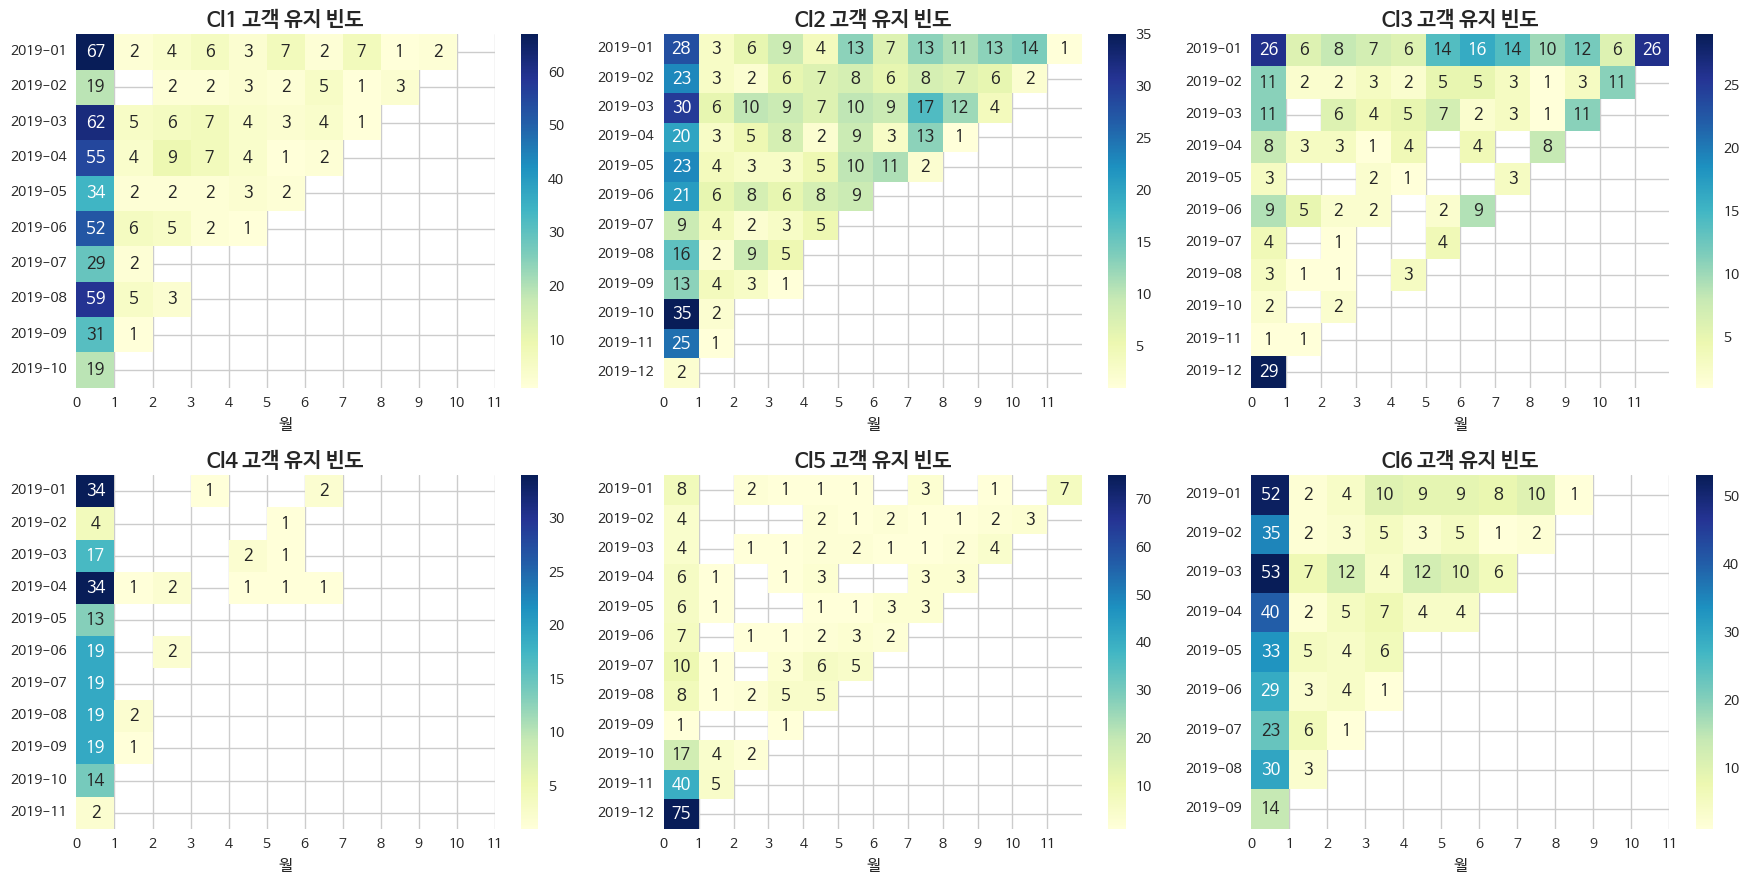

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for cluster_num, ax in zip(range(1, 7), axes.flat):
    ch_cl_temp = ch_cl[ch_cl['cluster'] == f'Cl{cluster_num}']
    cohort_count_temp = ch_cl_temp.groupby(["첫거래달", "cohortindex"])["고객ID"].nunique().unstack()

    sns.heatmap(cohort_count_temp, cmap='YlGnBu', annot=True, ax=ax)
    ax.set_xticks(range(0,12))
    ax.set_xlabel('월')
    ax.set_ylabel('')
    ax.set_title(f'Cl{cluster_num} 고객 유지 빈도', fontsize=15, fontweight='bold')
    ax.set_xticklabels(range(0,12), rotation=0)

plt.tight_layout()
plt.show()

### 고객 유지율

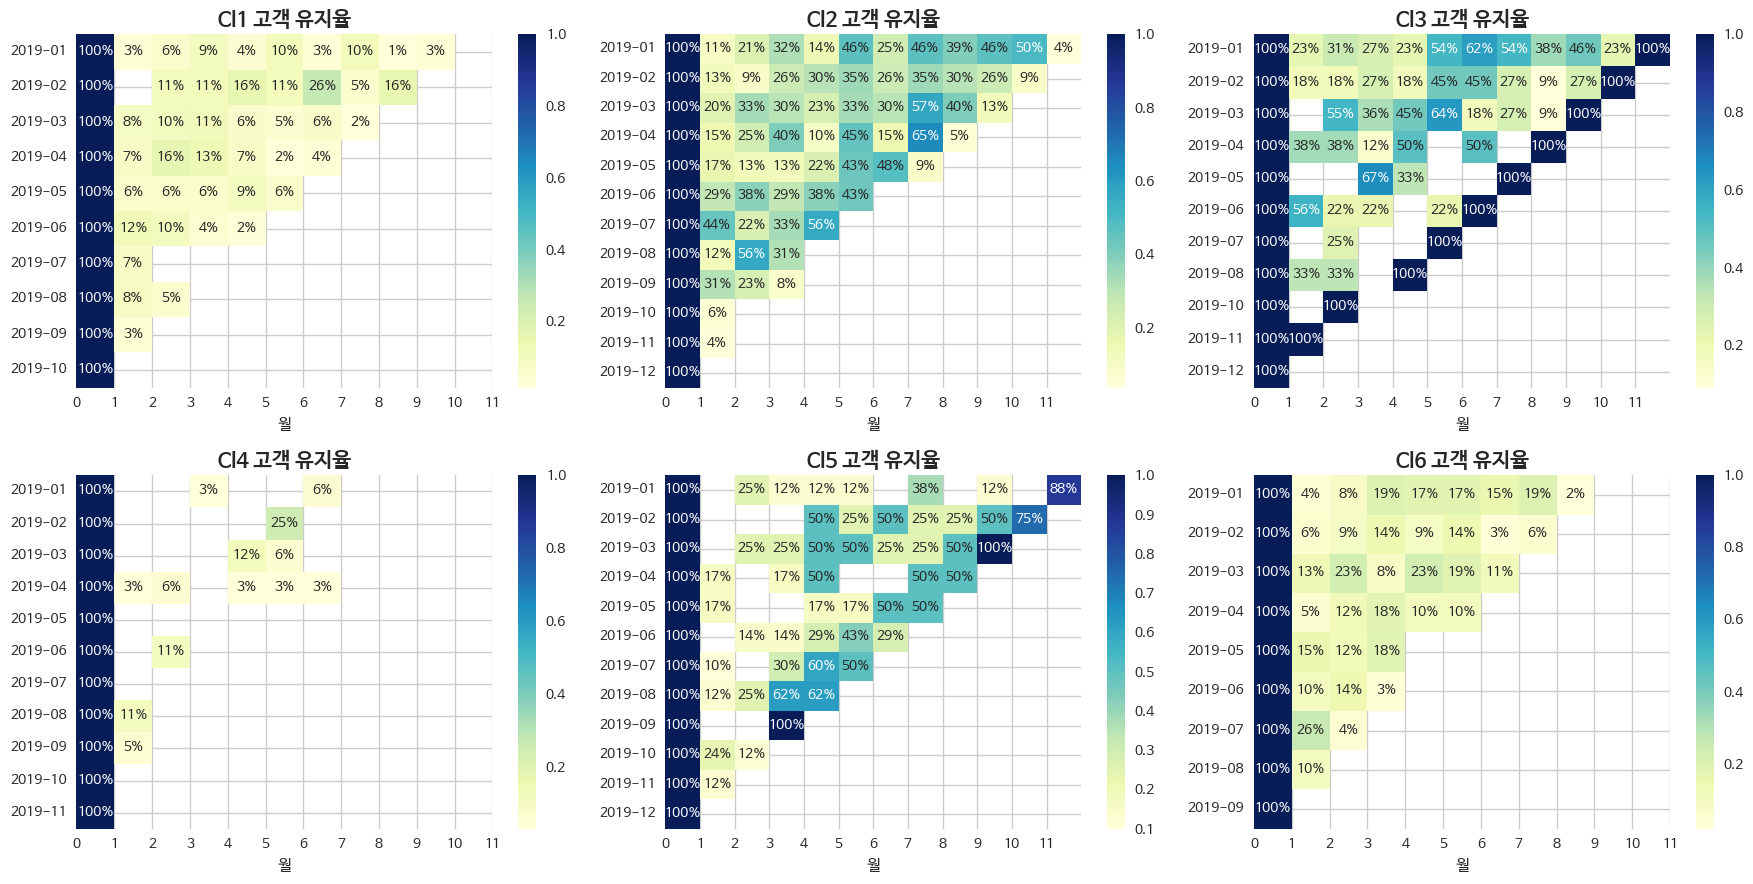

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for cluster_num, ax in zip(range(1, 7), axes.flat):
    ch_cl_temp = ch_cl[ch_cl['cluster'] == f'Cl{cluster_num}']
    cohort_count_temp = ch_cl_temp.groupby(["첫거래달", "cohortindex"])["고객ID"].nunique().unstack()
    cohort_norm_temp = cohort_count_temp.div(cohort_count_temp[0], axis=0)

    sns.heatmap(cohort_norm_temp, cmap='YlGnBu', annot=True, fmt='.0%', ax=ax, annot_kws={"fontsize":10})
    ax.set_xticks(range(0,12))
    ax.set_xlabel('월')
    ax.set_ylabel('')
    ax.set_title(f'Cl{cluster_num} 고객 유지율', fontsize=15, fontweight='bold')
    ax.set_xticklabels(range(0,12), rotation=0)

plt.tight_layout()
plt.show()

### 평균 고객 유지율

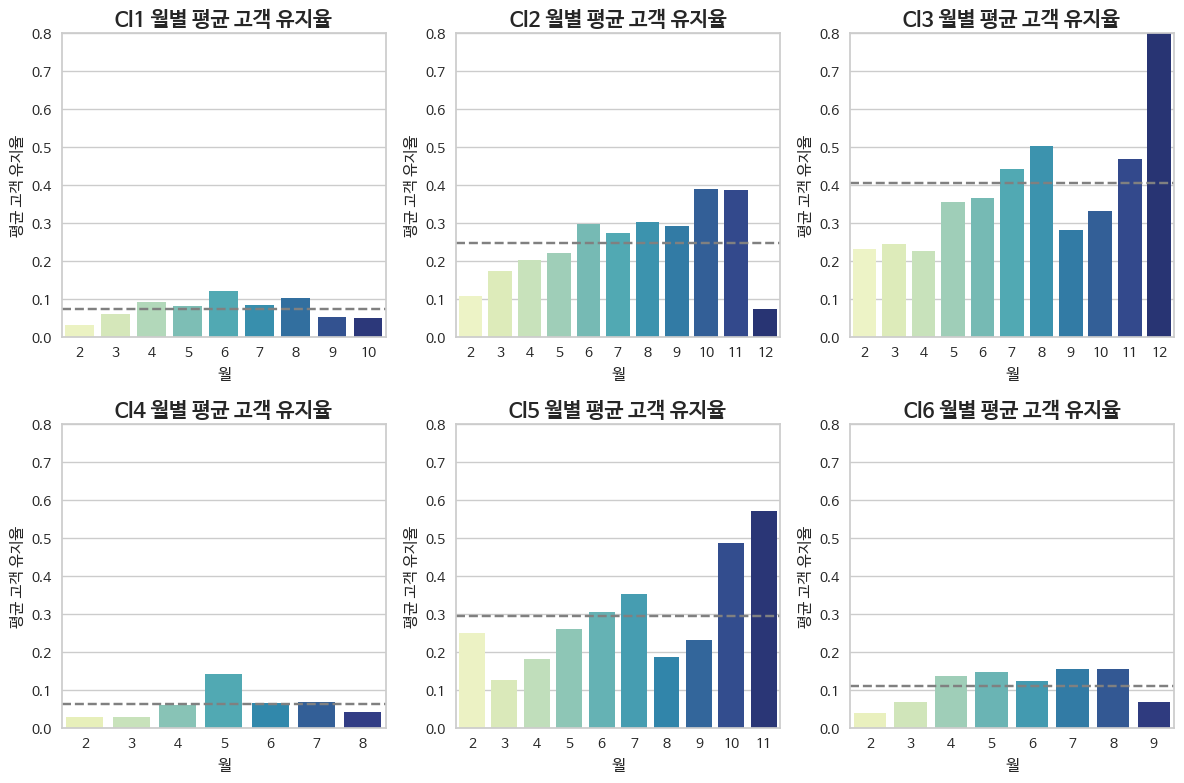

In [61]:
cohort_norm_list = [cohort_norm_1, cohort_norm_2, cohort_norm_3, cohort_norm_4, cohort_norm_5, cohort_norm_6]
plt.figure(figsize=(12,8))

for i, cohort_norm in enumerate(cohort_norm_list, start=1):
    avg_diagonals = average_diagonals(np.flipud(cohort_norm.iloc[:, 1:]))
    diag_mean_temp = pd.DataFrame({"고객 유지율 평균": avg_diagonals})
    diag_mean_temp = diag_mean_temp.dropna()

    new_index = range(2, len(diag_mean_temp) + 2)
    diag_mean_temp.index = new_index
    diag_mean_temp.reset_index(inplace=True)
    mean_value = diag_mean_temp["고객 유지율 평균"].mean()

    plt.subplot(2, 3, i)
    sns.barplot(data=diag_mean_temp, x='index', y='고객 유지율 평균', palette='YlGnBu')
    plt.axhline(y=mean_value, color='gray', linestyle='--', label=f'Cohort {i} 평균')
    plt.title(f'Cl{i} 월별 평균 고객 유지율', fontsize=15, fontweight='bold')
    plt.xlabel('월')
    plt.ylabel('평균 고객 유지율')
    plt.ylim(0, 0.8)

plt.tight_layout()
plt.show()

- Cl1, Cl4, Cl6은 고객 유지율이 전반적으로 낮고 Cl2, Cl3, Cl5은 고객 유지율이 높은 편이다.
- Cl3은 2월에 고객 유지율이 가장 낮고, 12월에 가장 높다.
- Cl5은 7월과 11월에 유지율이 높다.

### 매출액

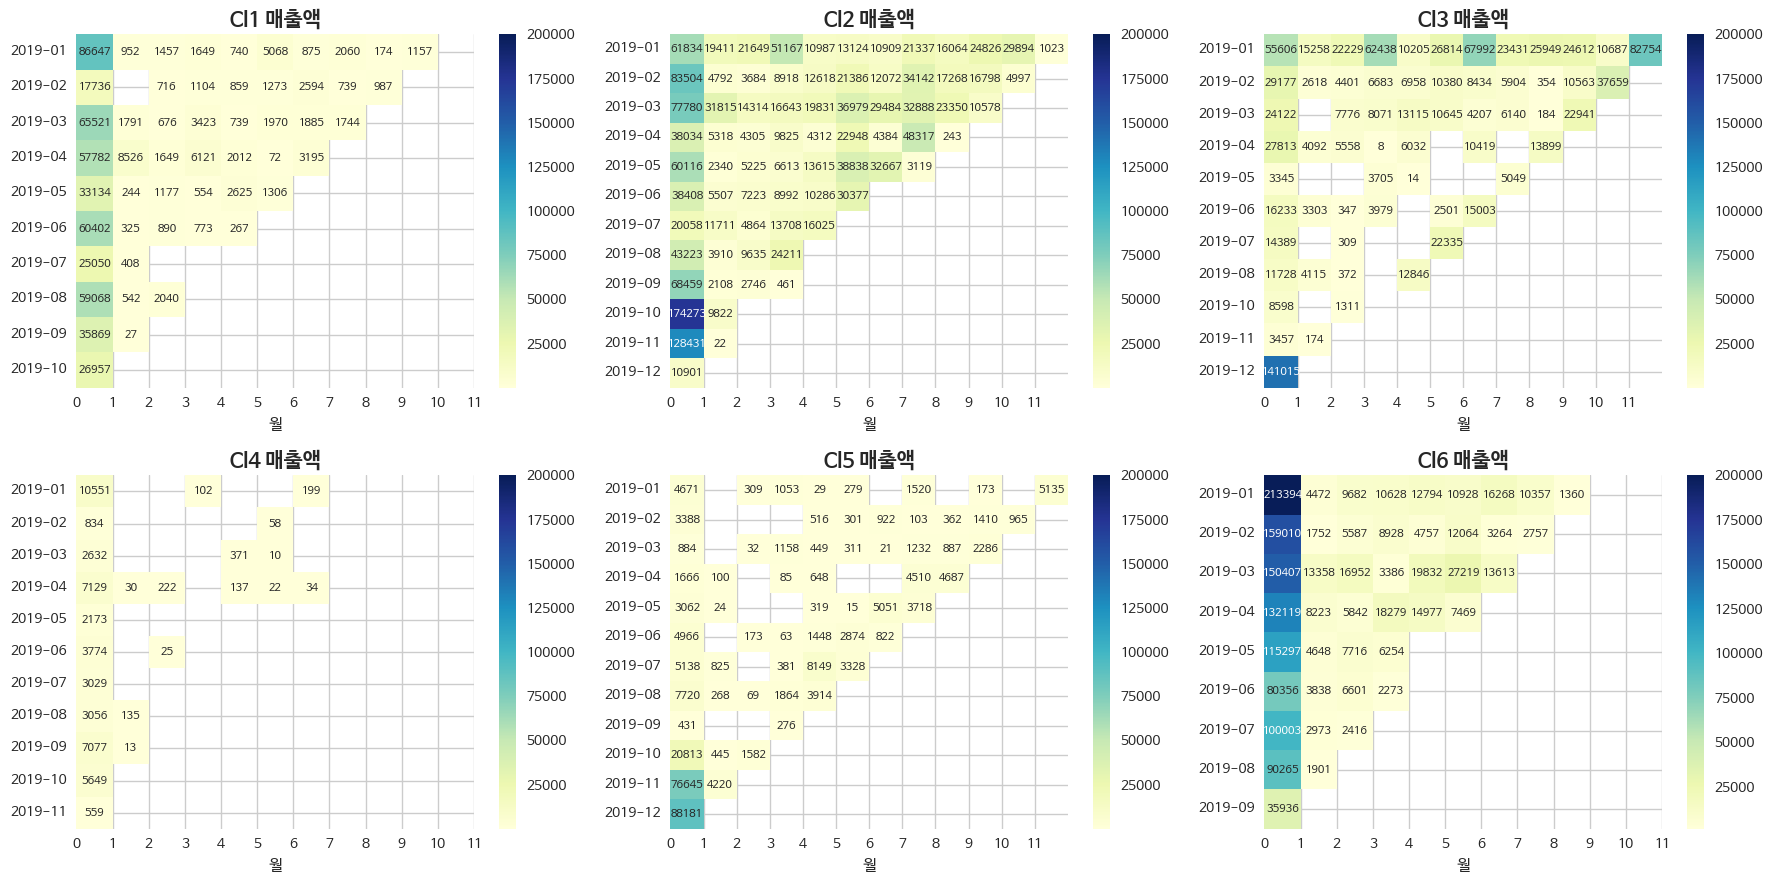

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for cluster_num, ax in zip(range(1, 7), axes.flat):
    ch_cl_temp = ch_cl[ch_cl['cluster'] == f'Cl{cluster_num}']
    cohort_total_price = ch_cl_temp.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()

    sns.heatmap(cohort_total_price, cmap='YlGnBu', annot=True, fmt='.0f', ax=ax, vmax = 200000, annot_kws={"fontsize":8})
    ax.set_xticks(range(0,12))
    ax.set_xlabel('월')
    ax.set_ylabel('')
    ax.set_title(f'Cl{cluster_num} 매출액', fontsize=15, fontweight='bold')
    ax.set_xticklabels(range(0,12), rotation=0)

plt.tight_layout()
plt.show()

### 평균 매출액

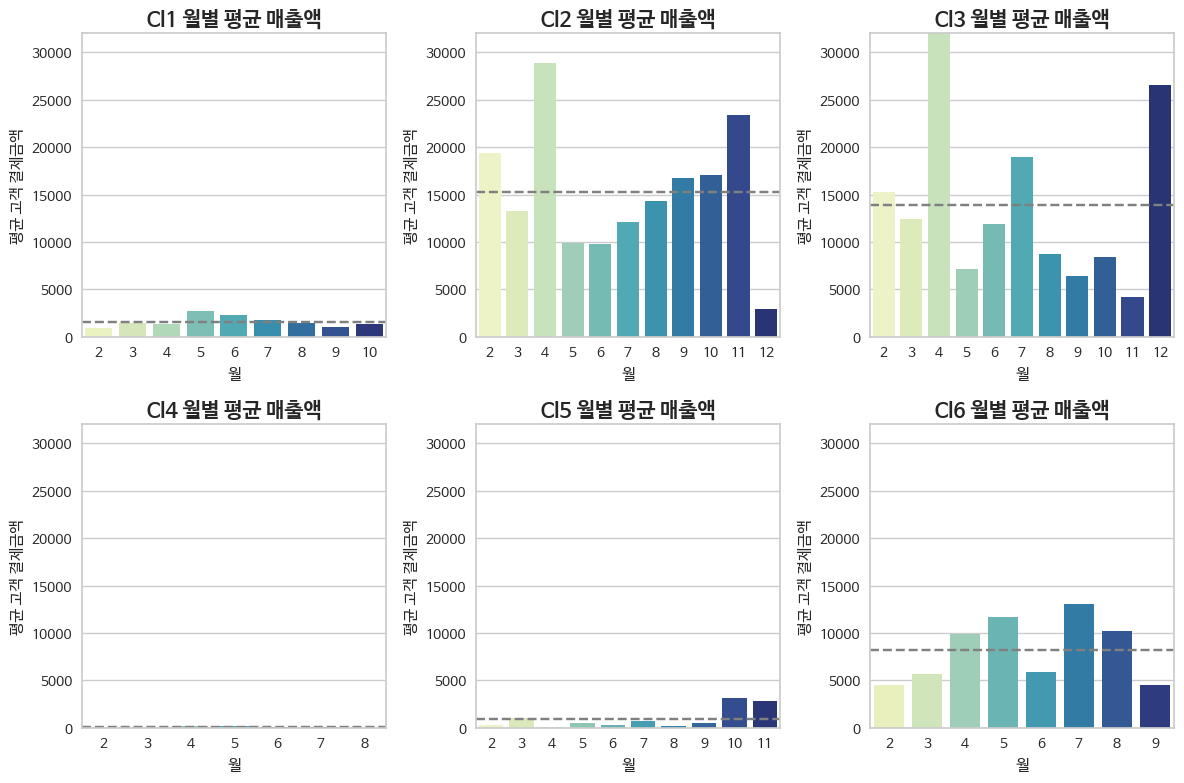

In [63]:
cohort_total_price_1 = ch_cl_1.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()
cohort_total_price_2 = ch_cl_2.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()
cohort_total_price_3 = ch_cl_3.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()
cohort_total_price_4 = ch_cl_4.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()
cohort_total_price_5 = ch_cl_5.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()
cohort_total_price_6 = ch_cl_6.groupby(["첫거래달", "cohortindex"])["최종결제금액"].sum().unstack()
cohort_price_list = [cohort_total_price_1, cohort_total_price_2, cohort_total_price_3, cohort_total_price_4, cohort_total_price_5, cohort_total_price_6]

plt.figure(figsize=(12,8))
for i, cohort_price in enumerate(cohort_price_list, start=1):
    avg_diagonals = average_diagonals(np.flipud(cohort_price.iloc[:, 1:]))
    diag_mean_temp = pd.DataFrame({"결제 금액 평균": avg_diagonals})
    diag_mean_temp = diag_mean_temp.dropna()

    new_index = range(2, len(diag_mean_temp) + 2)
    diag_mean_temp.index = new_index
    diag_mean_temp.reset_index(inplace=True)
    mean_value = diag_mean_temp["결제 금액 평균"].mean()

    plt.subplot(2, 3, i)
    sns.barplot(data=diag_mean_temp, x='index', y='결제 금액 평균', palette='YlGnBu')
    plt.axhline(y=mean_value, color='gray', linestyle='--', label=f'Cohort {i} 평균')
    plt.title(f'Cl{i} 월별 평균 매출액', fontsize=15, fontweight='bold')
    plt.xlabel('월')
    plt.ylabel('평균 고객 결제금액')
    plt.ylim(0, 32000)

plt.tight_layout()
plt.show()